# Task 3 — Improve, Compare, and Explain the EEG ST-GNN

**Dataset:** PhysioNet EEG Motor Movement/Imagery Database (EEGMMIDB)  
**Task:** Left-fist versus right-fist motor execution  
**Protocol:** Leakage-free subject-independent evaluation  
**Presentation:** Saturday, 8 August

This notebook continues the executed Task 2 experiment. It uses the reusable graph dataset exported by Task 2 and implements:

1. controlled ablations of graph type, edge weighting, GNN family, depth, hidden size, dropout, normalization, optimizer, learning-rate schedule, imbalance handling, and early stopping;
2. a redesigned laterality-aware ST-GNN;
3. five-fold subject-level cross-validation;
4. comparison of the final GNN with the first Task 2 GNN and the strongest Task 2 baseline;
5. a paired subject-level significance test;
6. SHAP and LIME explanations for one correct and one incorrect out-of-fold prediction;
7. export of report-ready tables, figures, checkpoints, and predictions.

> **Important:** This notebook never uses outer-fold labels for graph construction, scaling, early stopping, or model selection. Numerical results are produced only after execution.


## Research decisions carried forward from Task 2

The executed Task 2 notebook found that:

- the **1D-CNN** was the strongest overall baseline, with approximately 65.96% test accuracy;
- the first Hybrid ST-GNN achieved approximately 50.99% and was close to chance;
- the original GNN globally pooled electrodes without explicit electrode identity or hemisphere encoding;
- graph construction used 40% anatomical and 60% training-only functional adjacency.

Task 3 therefore treats the 1D-CNN as the baseline to beat and tests whether graph design, positional information, laterality-aware pooling, and optimization changes improve subject-independent performance.


## 1. Environment, dependencies, and reproducibility


In [1]:
import importlib.util
import json
import math
import os
import random
import re
import subprocess
import sys
import time
import warnings
from collections import Counter
from copy import deepcopy
from dataclasses import dataclass
from pathlib import Path

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "torch": "torch",
    "joblib": "joblib",
    "shap": "shap",
}

missing_packages = [
    pip_name
    for module_name, pip_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module_name) is None
]
if missing_packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_packages]
    )

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import torch
import torch.nn as nn
import torch.nn.functional as F

from scipy.spatial.distance import cdist
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

warnings.filterwarnings("default")

def seed_everything(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)


Python: 3.12.13
PyTorch: 2.10.0+cu128
Device: cuda


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 2. Task 3 configuration


In [2]:
# Execution controls
RUN_FULL_ABLATION = True
RUN_FIVE_FOLD_CV = True
RUN_EXPLAINABILITY = True

# Training controls
ABLATION_EPOCHS = 12
CV_EPOCHS = 20
BATCH_SIZE = 64
NUM_WORKERS = 0
GRADIENT_CLIP = 3.0
LABEL_SMOOTHING = 0.03
WEIGHT_DECAY = 3e-4
N_SPLITS = 5
INNER_VALIDATION_SIZE = 0.15
PERMUTATION_REPEATS = 50_000
BOOTSTRAP_REPEATS = 10_000

# Task 2 carried-forward baseline
BEST_BASELINE_NAME = "1D-CNN"
FIRST_GNN_NAME = "First Hybrid ST-GNN"
FINAL_GNN_NAME = "Task 3 Laterality-Aware ST-GNN"

# Output paths
OUTPUT_DIR = Path("/kaggle/working/eeg_task3_output")
if not Path("/kaggle/working").exists():
    OUTPUT_DIR = Path("./eeg_task3_output")

MODEL_DIR = OUTPUT_DIR / "models"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
for folder in [OUTPUT_DIR, MODEL_DIR, FIGURE_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR.resolve())


Output directory: /kaggle/working/eeg_task3_output


## 3. Locate and load the reusable Task 2 graph dataset


In [3]:
def locate_task2_dataset() -> Path:
    # 1. Direct explicit file paths or directory targets
    explicit_paths = [
        Path("/kaggle/input/datasets/asfarhossain/ir-execution-subject-holdout-64ch-graph-dataset"),
        Path("/kaggle/input/ir-execution-subject-holdout-64ch-graph-dataset"),
    ]
    
    # Check explicit paths directly (handles both direct file or folder targets)
    for p in explicit_paths:
        if p.is_file():
            return p.resolve()
        if p.is_dir():
            # Find any .npz file inside the mounted dataset directory
            npz_files = list(p.rglob("*.npz"))
            if npz_files:
                return npz_files[0].resolve()

    # 2. Search fallback across common Kaggle directories
    patterns = ["*64ch_graph_dataset*.npz", "*.npz"]
    roots = [
        Path("/kaggle/working"),
        Path("/kaggle/input"),
        Path("."),
        Path("/mnt/data"),
    ]
    
    candidates = []
    for root in roots:
        if not root.exists():
            continue
        for pattern in patterns:
            candidates.extend(root.rglob(pattern))

    candidates = sorted(
        {path.resolve() for path in candidates if path.is_file()},
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    
    if not candidates:
        raise FileNotFoundError(
            "Task 2 graph dataset was not found. Verify that the Kaggle dataset "
            "is attached to your notebook input."
        )
        
    print("Dataset candidates found:")
    for candidate in candidates[:10]:
        print(" -", candidate)
        
    return candidates[0]


DATASET_PATH = locate_task2_dataset()
data = np.load(DATASET_PATH, allow_pickle=True)

required_keys = {
    "X_model",
    "node_features",
    "y",
    "subjects",
    "channel_names",
    "class_names",
    "anatomical_adjacency",
}
missing_keys = required_keys.difference(data.files)
if missing_keys:
    raise KeyError(f"Missing required Task 2 arrays: {sorted(missing_keys)}")

X = data["X_model"].astype(np.float32)
NODE_FEATURES = data["node_features"].astype(np.float32)
Y = data["y"].astype(np.int64)
SUBJECTS = data["subjects"]
CHANNEL_NAMES = data["channel_names"].astype(str).tolist()
CLASS_NAMES = data["class_names"].astype(str).tolist()
ANATOMICAL_ADJACENCY = data["anatomical_adjacency"].astype(np.float32)

TASK2_TRAIN_IDX = data["train_idx"].astype(np.int64)
TASK2_VAL_IDX = data["val_idx"].astype(np.int64)
TASK2_TEST_IDX = data["test_idx"].astype(np.int64)

NODE_FEATURE_NAMES = [
    "logrel_mu_8_12",
    "logrel_low_beta_12_16",
    "logrel_mid_beta_16_20",
    "logrel_high_beta_20_24",
    "logrel_upper_beta_24_30",
    "log_variance",
    "log_rms",
    "log_line_length",
    "zero_crossing_rate",
    "hjorth_mobility",
]
if NODE_FEATURES.shape[-1] != len(NODE_FEATURE_NAMES):
    NODE_FEATURE_NAMES = [
        f"node_feature_{i}" for i in range(NODE_FEATURES.shape[-1])
    ]

N_CLASSES = len(np.unique(Y))
N_CHANNELS = X.shape[1]
N_TIMES = X.shape[2]
N_NODE_FEATURES = NODE_FEATURES.shape[-1]

assert len(X) == len(NODE_FEATURES) == len(Y) == len(SUBJECTS)
assert ANATOMICAL_ADJACENCY.shape == (N_CHANNELS, N_CHANNELS)

print("Loaded:", DATASET_PATH)
print("Signal tensor:", X.shape)
print("Node features:", NODE_FEATURES.shape)
print("Subjects:", len(np.unique(SUBJECTS)))
print("Classes:", dict(Counter(Y)))
print("Channels:", N_CHANNELS, "| Time samples:", N_TIMES)

Dataset candidates found:
 - /kaggle/input/notebooks/asfarhossainsitab/task2-eeg-baselines-hybrid-stgnn-20epoch/eeg_task2_output/lr_execution_subject_holdout_64ch_graph_dataset.npz
 - /kaggle/input/notebooks/asfarhossainsitab/task2-eeg-baselines-hybrid-stgnn-20epoch/eeg_task2_output/cache/lr_execution_s109_100hz_8-30hz_ptp350.npz
 - /kaggle/input/notebooks/asfarhossainsitab/task2-eeg-baselines-hybrid-stgnn-20epoch/eeg_task2_output/cache/lr_execution_s109_100hz_8-30hz_ptp350_node_features.npz
Loaded: /kaggle/input/notebooks/asfarhossainsitab/task2-eeg-baselines-hybrid-stgnn-20epoch/eeg_task2_output/lr_execution_subject_holdout_64ch_graph_dataset.npz
Signal tensor: (4548, 64, 400)
Node features: (4548, 64, 10)
Subjects: 108
Classes: {np.int64(0): 2276, np.int64(1): 2272}
Channels: 64 | Time samples: 400


## 4. Leakage and data-integrity audit


In [4]:
def subject_set(indices):
    return set(np.asarray(SUBJECTS)[np.asarray(indices)].tolist())

task2_overlap = {
    "train_validation": len(subject_set(TASK2_TRAIN_IDX) & subject_set(TASK2_VAL_IDX)),
    "train_test": len(subject_set(TASK2_TRAIN_IDX) & subject_set(TASK2_TEST_IDX)),
    "validation_test": len(subject_set(TASK2_VAL_IDX) & subject_set(TASK2_TEST_IDX)),
}
assert sum(task2_overlap.values()) == 0, task2_overlap

audit = pd.Series(
    {
        "trials": len(Y),
        "subjects": len(np.unique(SUBJECTS)),
        "channels": N_CHANNELS,
        "time_samples": N_TIMES,
        "node_features_per_channel": N_NODE_FEATURES,
        "missing_signal_values": int(np.isnan(X).sum()),
        "missing_node_feature_values": int(np.isnan(NODE_FEATURES).sum()),
        "class_0_trials": int(np.sum(Y == 0)),
        "class_1_trials": int(np.sum(Y == 1)) if N_CLASSES == 2 else np.nan,
        **{f"task2_overlap_{key}": value for key, value in task2_overlap.items()},
    }
)
display(audit.to_frame("value"))

assert np.isfinite(X).all()
assert np.isfinite(NODE_FEATURES).all()


,value
trials,4548
subjects,108
channels,64
time_samples,400
node_features_per_channel,10
missing_signal_values,0
missing_node_feature_values,0
class_0_trials,2276
class_1_trials,2272
task2_overlap_train_validation,0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 5. Evaluation logic

Two stages are kept separate:

### Stage A — controlled ablation

The original Task 2 training subjects are used for fitting and its validation subjects are used for choosing the improved GNN configuration. The Task 2 test subjects are not used in this stage.

### Stage B — five-fold subject-level comparison

Five-fold GroupKFold is applied to the Task 2 development population (`train + validation`). Every outer fold contains unseen subjects. Within each outer-training partition, another subject-level split provides an inner validation set for early stopping. The outer fold is not used for scaling, graph construction, or early stopping.

The fixed Task 2 test set remains excluded from hyperparameter selection. Because it was already inspected in Task 2, the primary Task 3 evidence is the paired five-fold result rather than a claim of a newly untouched test set.


## 6. Metrics and statistical helpers


In [5]:
def probability_metrics(y_true, probabilities):
    probabilities = np.asarray(probabilities, dtype=float)
    probabilities = np.clip(probabilities, 1e-7, 1.0)
    probabilities = probabilities / probabilities.sum(
        axis=1, keepdims=True
    )
    predictions = probabilities.argmax(axis=1)

    result = {
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision_macro": precision_score(
            y_true, predictions, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, predictions, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_true, predictions, average="macro", zero_division=0
        ),
        "f1_weighted": f1_score(
            y_true, predictions, average="weighted", zero_division=0
        ),
        "mcc": matthews_corrcoef(y_true, predictions),
        "cohen_kappa": cohen_kappa_score(y_true, predictions),
        "log_loss": log_loss(
            y_true,
            np.clip(probabilities, 1e-7, 1 - 1e-7),
            labels=np.arange(N_CLASSES),
        ),
    }
    try:
        if N_CLASSES == 2:
            result["roc_auc"] = roc_auc_score(y_true, probabilities[:, 1])
        else:
            result["roc_auc"] = roc_auc_score(
                y_true, probabilities, multi_class="ovr", average="macro"
            )
    except ValueError:
        result["roc_auc"] = np.nan
    return result


def paired_sign_flip_test(differences, n_permutations=50_000, seed=42):
    """Paired two-sided randomization test on subject-level metric differences."""
    differences = np.asarray(differences, dtype=float)
    differences = differences[np.isfinite(differences)]
    observed = float(np.mean(differences))
    rng = np.random.default_rng(seed)
    exceedances = 0
    batch_size = 2_000

    for start in range(0, n_permutations, batch_size):
        batch = min(batch_size, n_permutations - start)
        signs = rng.choice([-1.0, 1.0], size=(batch, len(differences)))
        permuted = np.mean(signs * differences[None, :], axis=1)
        exceedances += int(np.sum(np.abs(permuted) >= abs(observed)))

    p_value = (exceedances + 1) / (n_permutations + 1)
    return observed, float(p_value)


def subject_bootstrap_ci(differences, repeats=10_000, seed=42):
    differences = np.asarray(differences, dtype=float)
    rng = np.random.default_rng(seed)
    samples = rng.choice(
        differences,
        size=(repeats, len(differences)),
        replace=True,
    )
    means = samples.mean(axis=1)
    return tuple(np.quantile(means, [0.025, 0.975]).tolist())


## 7. Fold-specific graph construction


In [6]:
def functional_adjacency_from_training(
    X_train,
    k=8,
    max_trials=1000,
    seed=42,
):
    rng = np.random.default_rng(seed)
    X_used = X_train
    if len(X_used) > max_trials:
        selected = rng.choice(len(X_used), size=max_trials, replace=False)
        X_used = X_used[selected]

    channel_matrix = X_used.transpose(1, 0, 2).reshape(X_used.shape[1], -1)
    correlation = np.corrcoef(channel_matrix)
    correlation = np.nan_to_num(np.abs(correlation), nan=0.0)
    np.fill_diagonal(correlation, 0.0)

    adjacency = np.zeros_like(correlation, dtype=np.float32)
    for node in range(correlation.shape[0]):
        neighbours = np.argsort(correlation[node])[-k:]
        adjacency[node, neighbours] = correlation[node, neighbours]

    adjacency = np.maximum(adjacency, adjacency.T)
    return adjacency.astype(np.float32)


def normalize_adjacency(adjacency):
    adjacency = np.asarray(adjacency, dtype=np.float32)
    adjacency = adjacency + np.eye(adjacency.shape[0], dtype=np.float32)
    degree = adjacency.sum(axis=1)
    inv_sqrt = np.power(degree + 1e-8, -0.5)
    return (inv_sqrt[:, None] * adjacency * inv_sqrt[None, :]).astype(np.float32)


def build_fold_adjacency(X_train, config, seed=42):
    graph_method = config.get("graph_method", "hybrid")
    edge_mode = config.get("edge_mode", "weighted")
    functional_k = int(config.get("functional_k", 8))

    anatomical = ANATOMICAL_ADJACENCY.copy()
    functional = functional_adjacency_from_training(
        X_train,
        k=functional_k,
        seed=seed,
    )

    if graph_method == "identity":
        raw = np.zeros_like(anatomical, dtype=np.float32)
    elif graph_method == "anatomical":
        raw = anatomical
    elif graph_method == "functional":
        raw = functional
    elif graph_method == "hybrid":
        anatomical_weight = float(config.get("anatomical_weight", 0.40))
        functional_weight = float(config.get("functional_weight", 0.60))
        total = anatomical_weight + functional_weight
        if total <= 0:
            raise ValueError("Hybrid graph weights must sum to a positive number.")
        raw = (
            anatomical_weight / total * anatomical
            + functional_weight / total * functional
        )
    else:
        raise ValueError(f"Unknown graph method: {graph_method}")

    if edge_mode == "binary":
        raw = (raw > 0).astype(np.float32)
    elif edge_mode != "weighted":
        raise ValueError(f"Unknown edge mode: {edge_mode}")

    normalized = normalize_adjacency(raw)
    return normalized, anatomical, functional


## 8. Channel identity, hemisphere, and motor-region encodings


In [7]:
def channel_structural_features(channel_names):
    rows = []
    left_mask = []
    right_mask = []
    midline_mask = []

    for name in channel_names:
        match = re.search(r"(\d+)$", name)
        number = int(match.group(1)) if match else None
        is_midline = name.lower().endswith("z") or number is None
        is_left = bool(number is not None and number % 2 == 1)
        is_right = bool(number is not None and number % 2 == 0)
        is_motor_region = bool(re.match(r"^(FC|C|CP)", name, flags=re.IGNORECASE))

        hemisphere = -1.0 if is_left else (1.0 if is_right else 0.0)
        rows.append([hemisphere, float(is_motor_region)])
        left_mask.append(is_left)
        right_mask.append(is_right)
        midline_mask.append(is_midline)

    return (
        np.asarray(rows, dtype=np.float32),
        np.asarray(left_mask, dtype=bool),
        np.asarray(right_mask, dtype=bool),
        np.asarray(midline_mask, dtype=bool),
    )

(
    STRUCTURAL_FEATURES,
    LEFT_MASK,
    RIGHT_MASK,
    MIDLINE_MASK,
) = channel_structural_features(CHANNEL_NAMES)

print("Left channels:", int(LEFT_MASK.sum()))
print("Right channels:", int(RIGHT_MASK.sum()))
print("Midline/other channels:", int(MIDLINE_MASK.sum()))
print("Motor-region channels:", int(STRUCTURAL_FEATURES[:, 1].sum()))


Left channels: 27
Right channels: 27
Midline/other channels: 10
Motor-region channels: 21


## 9. Fold-specific scaling and PyTorch datasets


In [8]:
@dataclass
class FoldBundle:
    train_idx: np.ndarray
    val_idx: np.ndarray
    test_idx: np.ndarray
    channel_mean: np.ndarray
    channel_std: np.ndarray
    feature_mean: np.ndarray
    feature_std: np.ndarray
    adjacency: np.ndarray
    train_loader: DataLoader
    train_eval_loader: DataLoader
    val_loader: DataLoader
    test_loader: DataLoader


class FoldEEGDataset(Dataset):
    def __init__(
        self,
        indices,
        channel_mean,
        channel_std,
        feature_mean,
        feature_std,
        augment=False,
    ):
        self.indices = np.asarray(indices, dtype=np.int64)
        self.channel_mean = channel_mean
        self.channel_std = channel_std
        self.feature_mean = feature_mean
        self.feature_std = feature_std
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    @staticmethod
    def augment_signal(signal):
        if np.random.rand() < 0.45:
            signal = signal * np.random.uniform(0.95, 1.05)
        if np.random.rand() < 0.35:
            signal = signal + np.random.normal(
                0.0, 0.012, size=signal.shape
            ).astype(np.float32)
        if np.random.rand() < 0.25:
            signal = np.roll(signal, np.random.randint(-5, 6), axis=-1)
        if np.random.rand() < 0.15:
            width = np.random.randint(4, 13)
            start = np.random.randint(0, signal.shape[-1] - width + 1)
            signal[:, start:start + width] = 0.0
        return signal

    def __getitem__(self, item):
        index = int(self.indices[item])
        signal = X[index].copy()
        signal = (
            signal - self.channel_mean[:, None]
        ) / self.channel_std[:, None]

        node_features = NODE_FEATURES[index].copy()
        node_features = (
            node_features - self.feature_mean[None, :]
        ) / self.feature_std[None, :]

        if self.augment:
            signal = self.augment_signal(signal)

        return (
            torch.from_numpy(signal.astype(np.float32)),
            torch.from_numpy(node_features.astype(np.float32)),
            torch.tensor(Y[index], dtype=torch.long),
            torch.tensor(index, dtype=torch.long),
        )


def make_fold_bundle(
    train_idx,
    val_idx,
    test_idx,
    model_config,
    seed=42,
):
    train_idx = np.asarray(train_idx, dtype=np.int64)
    val_idx = np.asarray(val_idx, dtype=np.int64)
    test_idx = np.asarray(test_idx, dtype=np.int64)

    train_subjects = subject_set(train_idx)
    val_subjects = subject_set(val_idx)
    test_subjects = subject_set(test_idx)
    assert not (train_subjects & val_subjects)
    assert not (train_subjects & test_subjects)
    assert not (val_subjects & test_subjects)

    channel_mean = X[train_idx].mean(axis=(0, 2)).astype(np.float32)
    channel_std = X[train_idx].std(axis=(0, 2)).astype(np.float32)
    channel_std = np.maximum(channel_std, 1e-3)

    feature_mean = NODE_FEATURES[train_idx].mean(axis=(0, 1)).astype(np.float32)
    feature_std = NODE_FEATURES[train_idx].std(axis=(0, 1)).astype(np.float32)
    feature_std = np.maximum(feature_std, 1e-4)

    adjacency, _, _ = build_fold_adjacency(
        X[train_idx],
        model_config,
        seed=seed,
    )

    train_dataset = FoldEEGDataset(
        train_idx,
        channel_mean,
        channel_std,
        feature_mean,
        feature_std,
        augment=True,
    )
    train_eval_dataset = FoldEEGDataset(
        train_idx,
        channel_mean,
        channel_std,
        feature_mean,
        feature_std,
        augment=False,
    )
    val_dataset = FoldEEGDataset(
        val_idx,
        channel_mean,
        channel_std,
        feature_mean,
        feature_std,
        augment=False,
    )
    test_dataset = FoldEEGDataset(
        test_idx,
        channel_mean,
        channel_std,
        feature_mean,
        feature_std,
        augment=False,
    )

    imbalance_handling = model_config.get(
        "imbalance_handling", "class_weight"
    )
    sampler = None
    shuffle = True

    if imbalance_handling == "sampler":
        class_counts = np.bincount(Y[train_idx], minlength=N_CLASSES)
        sample_weights = 1.0 / np.maximum(class_counts[Y[train_idx]], 1)
        generator = torch.Generator()
        generator.manual_seed(seed)
        sampler = WeightedRandomSampler(
            weights=torch.tensor(sample_weights, dtype=torch.double),
            num_samples=len(train_idx),
            replacement=True,
            generator=generator,
        )
        shuffle = False

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    train_eval_loader = DataLoader(
        train_eval_dataset,
        batch_size=BATCH_SIZE * 2,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE * 2,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE * 2,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )

    return FoldBundle(
        train_idx=train_idx,
        val_idx=val_idx,
        test_idx=test_idx,
        channel_mean=channel_mean,
        channel_std=channel_std,
        feature_mean=feature_mean,
        feature_std=feature_std,
        adjacency=adjacency,
        train_loader=train_loader,
        train_eval_loader=train_eval_loader,
        val_loader=val_loader,
        test_loader=test_loader,
    )


## 10. Best Task 2 baseline: compact 1D-CNN


In [9]:
class CompactEEG1DCNN(nn.Module):
    def __init__(self, n_channels, n_classes, dropout=0.20):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(n_channels, 96, kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(96),
            nn.GELU(),
            nn.MaxPool1d(2),
            nn.Conv1d(96, 128, kernel_size=9, padding=4, groups=4, bias=False),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.MaxPool1d(2),
            nn.Conv1d(128, 160, kernel_size=7, padding=3, groups=4, bias=False),
            nn.BatchNorm1d(160),
            nn.GELU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(160, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, signal, node_features=None):
        return self.classifier(self.features(signal))


## 11. First Task 2 Hybrid ST-GNN


In [10]:
class FirstSTGraphBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dropout):
        super().__init__()
        padding = kernel_size // 2

        self.temporal = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=(1, kernel_size),
                padding=(0, padding),
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
        )
        self.graph_mix = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
        )
        self.refine = nn.Sequential(
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=(1, 7),
                padding=(0, 3),
                groups=out_channels,
                bias=False,
            ),
            nn.Conv2d(out_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )
        self.residual = (
            nn.Identity()
            if in_channels == out_channels
            else nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        )
        self.pool = nn.AvgPool2d((1, 2))
        self.dropout = nn.Dropout(dropout)
        self.graph_gate = nn.Parameter(torch.tensor(0.70))

    def forward(self, x, adjacency):
        residual = self.residual(x)
        temporal = self.temporal(x)
        graph_signal = torch.einsum("nm,bcmt->bcnt", adjacency, temporal)
        gate = torch.sigmoid(self.graph_gate)
        mixed = gate * graph_signal + (1.0 - gate) * temporal
        mixed = self.graph_mix(mixed)
        mixed = self.refine(mixed)
        output = F.gelu(mixed + residual)
        return self.dropout(self.pool(output))


class FirstHybridSTGNN(nn.Module):
    def __init__(self, adjacency, n_node_features, n_classes, dropout=0.20):
        super().__init__()
        self.register_buffer(
            "adjacency", torch.tensor(adjacency, dtype=torch.float32)
        )
        self.block1 = FirstSTGraphBlock(1, 48, 15, dropout * 0.6)
        self.block2 = FirstSTGraphBlock(48, 80, 11, dropout)
        self.block3 = FirstSTGraphBlock(80, 112, 7, dropout)

        self.raw_attention = nn.Conv1d(112, 1, kernel_size=1)
        self.feature_projection = nn.Sequential(
            nn.Linear(n_node_features, 64),
            nn.LayerNorm(64),
            nn.GELU(),
        )
        self.feature_graph = nn.Sequential(
            nn.Linear(64, 64),
            nn.LayerNorm(64),
            nn.GELU(),
        )
        self.feature_attention = nn.Linear(64, 1)

        fusion_size = (112 * 2) + (64 * 2)
        self.classifier = nn.Sequential(
            nn.Linear(fusion_size, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 96),
            nn.GELU(),
            nn.Dropout(dropout * 0.75),
            nn.Linear(96, n_classes),
        )

    def forward(self, signal, node_features):
        raw = signal.unsqueeze(1)
        raw = self.block1(raw, self.adjacency)
        raw = self.block2(raw, self.adjacency)
        raw = self.block3(raw, self.adjacency)

        raw_nodes = raw.mean(dim=-1)
        raw_weights = torch.softmax(
            self.raw_attention(raw_nodes).squeeze(1), dim=-1
        )
        raw_attention_pool = torch.sum(
            raw_nodes * raw_weights.unsqueeze(1), dim=-1
        )
        raw_max_pool = raw_nodes.max(dim=-1).values

        features = self.feature_projection(node_features)
        features = torch.einsum(
            "nm,bmf->bnf", self.adjacency, features
        )
        features = self.feature_graph(features)
        feature_weights = torch.softmax(
            self.feature_attention(features).squeeze(-1), dim=-1
        )
        feature_attention_pool = torch.sum(
            features * feature_weights.unsqueeze(-1), dim=1
        )
        feature_max_pool = features.max(dim=1).values

        fused = torch.cat(
            [
                raw_attention_pool,
                raw_max_pool,
                feature_attention_pool,
                feature_max_pool,
            ],
            dim=1,
        )
        return self.classifier(fused)


## 12. Task 3 dense GCN, GraphSAGE, and GAT layers


In [11]:
class NodeBatchNorm(nn.Module):
    def __init__(self, hidden_size, enabled=True):
        super().__init__()
        self.norm = nn.BatchNorm1d(hidden_size) if enabled else nn.Identity()

    def forward(self, x):
        batch, nodes, hidden = x.shape
        x = x.reshape(batch * nodes, hidden)
        x = self.norm(x)
        return x.reshape(batch, nodes, hidden)


class DenseGCNLayer(nn.Module):
    def __init__(self, hidden_size, dropout, batch_norm):
        super().__init__()
        self.linear = nn.Linear(hidden_size, hidden_size, bias=False)
        self.norm = NodeBatchNorm(hidden_size, batch_norm)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, adjacency):
        propagated = torch.einsum("nm,bmh->bnh", adjacency, x)
        update = self.linear(propagated)
        update = self.norm(update)
        return F.gelu(x + self.dropout(update))


class DenseGraphSAGELayer(nn.Module):
    def __init__(self, hidden_size, dropout, batch_norm):
        super().__init__()
        self.linear = nn.Linear(hidden_size * 2, hidden_size, bias=False)
        self.norm = NodeBatchNorm(hidden_size, batch_norm)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, adjacency):
        neighbourhood = torch.einsum("nm,bmh->bnh", adjacency, x)
        update = self.linear(torch.cat([x, neighbourhood], dim=-1))
        update = self.norm(update)
        return F.gelu(x + self.dropout(update))


class DenseGATLayer(nn.Module):
    def __init__(
        self,
        hidden_size,
        dropout,
        batch_norm,
        heads=4,
    ):
        super().__init__()
        if hidden_size % heads != 0:
            heads = 1
        self.hidden_size = hidden_size
        self.heads = heads
        self.head_dim = hidden_size // heads
        self.query = nn.Linear(hidden_size, hidden_size, bias=False)
        self.key = nn.Linear(hidden_size, hidden_size, bias=False)
        self.value = nn.Linear(hidden_size, hidden_size, bias=False)
        self.output = nn.Linear(hidden_size, hidden_size, bias=False)
        self.norm = NodeBatchNorm(hidden_size, batch_norm)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, adjacency):
        batch, nodes, _ = x.shape
        query = self.query(x).view(
            batch, nodes, self.heads, self.head_dim
        )
        key = self.key(x).view(
            batch, nodes, self.heads, self.head_dim
        )
        value = self.value(x).view(
            batch, nodes, self.heads, self.head_dim
        )

        scores = torch.einsum(
            "bnhd,bmhd->bhnm", query, key
        ) / math.sqrt(self.head_dim)

        edge_mask = adjacency > 0
        scores = scores + torch.log(
            adjacency.clamp_min(1e-8)
        )[None, None, :, :]
        scores = scores.masked_fill(
            ~edge_mask[None, None, :, :],
            torch.finfo(scores.dtype).min,
        )

        attention = torch.softmax(scores, dim=-1)
        attention = self.dropout(attention)
        update = torch.einsum(
            "bhnm,bmhd->bnhd", attention, value
        ).reshape(batch, nodes, self.hidden_size)
        update = self.output(update)
        update = self.norm(update)
        return F.gelu(x + self.dropout(update))


## 13. Improved laterality-aware ST-GNN


In [12]:
class ChannelTemporalEncoder(nn.Module):
    def __init__(self, hidden_size, dropout):
        super().__init__()
        middle = max(16, hidden_size // 2)
        self.network = nn.Sequential(
            nn.Conv1d(1, middle, kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(middle),
            nn.GELU(),
            nn.AvgPool1d(2),
            nn.Conv1d(
                middle,
                hidden_size,
                kernel_size=9,
                padding=4,
                bias=False,
            ),
            nn.BatchNorm1d(hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.AdaptiveAvgPool1d(1),
        )

    def forward(self, signal):
        batch, nodes, time_points = signal.shape
        encoded = self.network(
            signal.reshape(batch * nodes, 1, time_points)
        )
        return encoded.squeeze(-1).reshape(batch, nodes, -1)


class LateralityAwareSTGNN(nn.Module):
    def __init__(
        self,
        adjacency,
        n_node_features,
        n_classes,
        hidden_size=64,
        n_layers=2,
        dropout=0.30,
        batch_norm=True,
        gnn_variant="gcn",
        position_dim=16,
    ):
        super().__init__()
        self.hidden_size = hidden_size
        self.register_buffer(
            "adjacency", torch.tensor(adjacency, dtype=torch.float32)
        )
        self.register_buffer(
            "structural_features",
            torch.tensor(STRUCTURAL_FEATURES, dtype=torch.float32),
        )
        self.register_buffer(
            "left_mask", torch.tensor(LEFT_MASK, dtype=torch.bool)
        )
        self.register_buffer(
            "right_mask", torch.tensor(RIGHT_MASK, dtype=torch.bool)
        )
        self.register_buffer(
            "midline_mask", torch.tensor(MIDLINE_MASK, dtype=torch.bool)
        )

        self.temporal_encoder = ChannelTemporalEncoder(
            hidden_size=hidden_size,
            dropout=dropout * 0.5,
        )
        self.node_feature_projection = nn.Sequential(
            nn.Linear(n_node_features, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.GELU(),
        )
        self.node_identity = nn.Embedding(N_CHANNELS, position_dim)
        self.fusion = nn.Sequential(
            nn.Linear(
                hidden_size * 2 + position_dim + 2,
                hidden_size,
            ),
            nn.LayerNorm(hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        layer_class = {
            "gcn": DenseGCNLayer,
            "graphsage": DenseGraphSAGELayer,
            "gat": DenseGATLayer,
        }[gnn_variant.lower()]

        self.graph_layers = nn.ModuleList(
            [
                layer_class(
                    hidden_size=hidden_size,
                    dropout=dropout,
                    batch_norm=batch_norm,
                )
                for _ in range(n_layers)
            ]
        )

        self.node_attention = nn.Linear(hidden_size, 1)
        pooled_size = hidden_size * 6
        self.classifier = nn.Sequential(
            nn.Linear(pooled_size, hidden_size * 2),
            nn.BatchNorm1d(hidden_size * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout * 0.75),
            nn.Linear(hidden_size, n_classes),
        )

    @staticmethod
    def masked_mean(x, mask):
        weights = mask.float()[None, :, None]
        denominator = weights.sum(dim=1).clamp_min(1.0)
        return (x * weights).sum(dim=1) / denominator

    def forward(self, signal, node_features, return_attention=False):
        raw_nodes = self.temporal_encoder(signal)
        feature_nodes = self.node_feature_projection(node_features)

        node_ids = torch.arange(
            N_CHANNELS, device=signal.device
        )
        identity = self.node_identity(node_ids)[None, :, :].expand(
            signal.shape[0], -1, -1
        )
        structure = self.structural_features[None, :, :].expand(
            signal.shape[0], -1, -1
        )

        x = self.fusion(
            torch.cat(
                [raw_nodes, feature_nodes, identity, structure],
                dim=-1,
            )
        )

        for layer in self.graph_layers:
            x = layer(x, self.adjacency)

        attention = torch.softmax(
            self.node_attention(x).squeeze(-1), dim=-1
        )
        attention_pool = torch.sum(
            x * attention.unsqueeze(-1), dim=1
        )
        global_max = x.max(dim=1).values
        left_mean = self.masked_mean(x, self.left_mask)
        right_mean = self.masked_mean(x, self.right_mask)
        lateral_difference = left_mean - right_mean
        midline_mean = self.masked_mean(x, self.midline_mask)

        pooled = torch.cat(
            [
                attention_pool,
                global_max,
                left_mean,
                right_mean,
                lateral_difference,
                midline_mean,
            ],
            dim=-1,
        )
        logits = self.classifier(pooled)

        if return_attention:
            return logits, attention
        return logits


## 14. Architecture diagram


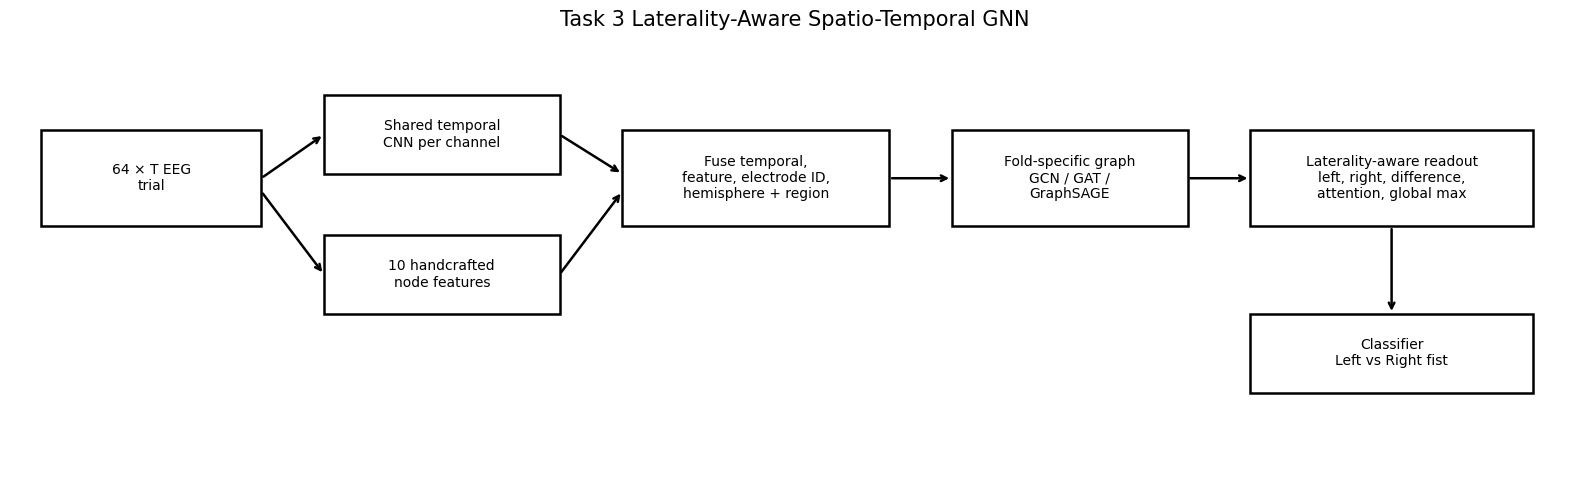

In [13]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.axis("off")

boxes = [
    (0.02, 0.58, 0.14, 0.22, "64 × T EEG\ntrial"),
    (0.20, 0.70, 0.15, 0.18, "Shared temporal\nCNN per channel"),
    (0.20, 0.38, 0.15, 0.18, "10 handcrafted\nnode features"),
    (0.39, 0.58, 0.17, 0.22, "Fuse temporal,\nfeature, electrode ID,\nhemisphere + region"),
    (0.60, 0.58, 0.15, 0.22, "Fold-specific graph\nGCN / GAT /\nGraphSAGE"),
    (0.79, 0.58, 0.18, 0.22, "Laterality-aware readout\nleft, right, difference,\nattention, global max"),
    (0.79, 0.20, 0.18, 0.18, "Classifier\nLeft vs Right fist"),
]

for x0, y0, width, height, label in boxes:
    rectangle = plt.Rectangle(
        (x0, y0),
        width,
        height,
        fill=False,
        linewidth=1.8,
    )
    ax.add_patch(rectangle)
    ax.text(
        x0 + width / 2,
        y0 + height / 2,
        label,
        ha="center",
        va="center",
        fontsize=10,
    )

arrows = [
    ((0.16, 0.69), (0.20, 0.79)),
    ((0.16, 0.66), (0.20, 0.47)),
    ((0.35, 0.79), (0.39, 0.70)),
    ((0.35, 0.47), (0.39, 0.66)),
    ((0.56, 0.69), (0.60, 0.69)),
    ((0.75, 0.69), (0.79, 0.69)),
    ((0.88, 0.58), (0.88, 0.38)),
]
for start, end in arrows:
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops={"arrowstyle": "->", "linewidth": 1.8},
    )

ax.set_title(
    "Task 3 Laterality-Aware Spatio-Temporal GNN",
    fontsize=15,
    pad=12,
)
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "task3_stgnn_architecture.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()


## 15. Model factory and training utilities


In [14]:
def count_parameters(model):
    return int(
        sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
    )


def make_model(model_name, adjacency, config):
    seed_everything(int(config.get("seed", SEED)))

    if model_name == BEST_BASELINE_NAME:
        return CompactEEG1DCNN(
            n_channels=N_CHANNELS,
            n_classes=N_CLASSES,
            dropout=float(config.get("dropout", 0.20)),
        )
    if model_name == FIRST_GNN_NAME:
        return FirstHybridSTGNN(
            adjacency=adjacency,
            n_node_features=N_NODE_FEATURES,
            n_classes=N_CLASSES,
            dropout=float(config.get("dropout", 0.20)),
        )
    if model_name == FINAL_GNN_NAME:
        return LateralityAwareSTGNN(
            adjacency=adjacency,
            n_node_features=N_NODE_FEATURES,
            n_classes=N_CLASSES,
            hidden_size=int(config.get("hidden_size", 64)),
            n_layers=int(config.get("n_layers", 2)),
            dropout=float(config.get("dropout", 0.30)),
            batch_norm=bool(config.get("batch_norm", True)),
            gnn_variant=str(config.get("gnn_variant", "gcn")),
            position_dim=int(config.get("position_dim", 16)),
        )
    raise ValueError(f"Unknown model name: {model_name}")


def predict_probabilities(model, loader):
    model.eval()
    probability_parts = []
    label_parts = []
    index_parts = []

    start = time.perf_counter()
    with torch.no_grad():
        for signal, node_features, labels, indices in loader:
            signal = signal.to(DEVICE, non_blocking=True)
            node_features = node_features.to(DEVICE, non_blocking=True)
            logits = model(signal, node_features)
            probability_parts.append(
                torch.softmax(logits, dim=1).cpu().numpy()
            )
            label_parts.append(labels.numpy())
            index_parts.append(indices.numpy())

    return (
        np.concatenate(probability_parts),
        np.concatenate(label_parts),
        np.concatenate(index_parts),
        time.perf_counter() - start,
    )


def make_optimizer(model, config):
    name = str(config.get("optimizer", "adamw")).lower()
    learning_rate = float(config.get("learning_rate", 8e-4))

    if name == "adamw":
        return torch.optim.AdamW(
            model.parameters(),
            lr=learning_rate,
            weight_decay=WEIGHT_DECAY,
        )
    if name == "adam":
        return torch.optim.Adam(
            model.parameters(),
            lr=learning_rate,
            weight_decay=WEIGHT_DECAY,
        )
    if name == "sgd":
        return torch.optim.SGD(
            model.parameters(),
            lr=learning_rate,
            momentum=0.9,
            nesterov=True,
            weight_decay=WEIGHT_DECAY,
        )
    raise ValueError(f"Unknown optimizer: {name}")


def make_scheduler(optimizer, config, epochs, steps_per_epoch):
    name = str(config.get("scheduler", "cosine")).lower()

    if name == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=max(1, epochs)
        ), "epoch"
    if name == "plateau":
        return torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
        ), "plateau"
    if name == "onecycle":
        return torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=float(config.get("learning_rate", 8e-4)),
            epochs=epochs,
            steps_per_epoch=max(1, steps_per_epoch),
            pct_start=0.25,
            anneal_strategy="cos",
            div_factor=10.0,
            final_div_factor=50.0,
        ), "batch"
    if name == "none":
        return None, "none"
    raise ValueError(f"Unknown scheduler: {name}")


def train_model(
    model_name,
    config,
    bundle,
    epochs,
    checkpoint_path,
):
    seed = int(config.get("seed", SEED))
    seed_everything(seed)
    model = make_model(model_name, bundle.adjacency, config).to(DEVICE)

    if config.get("imbalance_handling", "class_weight") == "class_weight":
        class_counts = np.bincount(
            Y[bundle.train_idx],
            minlength=N_CLASSES,
        )
        class_weights = len(bundle.train_idx) / (
            N_CLASSES * np.maximum(class_counts, 1)
        )
        class_weights = torch.tensor(
            class_weights,
            dtype=torch.float32,
            device=DEVICE,
        )
    else:
        class_weights = None

    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=float(
            config.get("label_smoothing", LABEL_SMOOTHING)
        ),
    )
    optimizer = make_optimizer(model, config)
    scheduler, scheduler_mode = make_scheduler(
        optimizer,
        config,
        epochs=epochs,
        steps_per_epoch=len(bundle.train_loader),
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=DEVICE.type == "cuda",
    )

    patience = int(config.get("patience", 6))
    use_early_stopping = bool(config.get("early_stopping", True))
    best_state = None
    best_epoch = 0
    best_val_f1 = -np.inf
    no_improvement = 0
    history = []
    training_start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum = 0.0

        for signal, node_features, labels, _ in bundle.train_loader:
            signal = signal.to(DEVICE, non_blocking=True)
            node_features = node_features.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=DEVICE.type == "cuda",
            ):
                logits = model(signal, node_features)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), GRADIENT_CLIP
            )
            scaler.step(optimizer)
            scaler.update()

            if scheduler_mode == "batch":
                scheduler.step()

            loss_sum += float(loss.item()) * len(labels)

        train_probs, train_labels, _, _ = predict_probabilities(
            model, bundle.train_eval_loader
        )
        val_probs, val_labels, _, _ = predict_probabilities(
            model, bundle.val_loader
        )
        train_metrics = probability_metrics(train_labels, train_probs)
        val_metrics = probability_metrics(val_labels, val_probs)

        if scheduler_mode == "epoch":
            scheduler.step()
        elif scheduler_mode == "plateau":
            scheduler.step(val_metrics["f1_macro"])

        row = {
            "epoch": epoch,
            "learning_rate": optimizer.param_groups[0]["lr"],
            "train_loss": loss_sum / len(bundle.train_idx),
            **{f"train_{key}": value for key, value in train_metrics.items()},
            **{f"val_{key}": value for key, value in val_metrics.items()},
        }
        history.append(row)

        print(
            f"{model_name} | epoch {epoch:02d}/{epochs} | "
            f"train F1={train_metrics['f1_macro']:.4f} | "
            f"val F1={val_metrics['f1_macro']:.4f}"
        )

        if val_metrics["f1_macro"] > best_val_f1 + 1e-4:
            best_val_f1 = val_metrics["f1_macro"]
            best_epoch = epoch
            no_improvement = 0
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
        else:
            no_improvement += 1

        if (
            use_early_stopping
            and no_improvement >= patience
            and epoch < epochs
        ):
            print(f"Early stopping at epoch {epoch}.")
            break

    training_seconds = time.perf_counter() - training_start
    if best_state is None:
        raise RuntimeError("No valid checkpoint was produced.")

    model.load_state_dict(best_state)
    model.to(DEVICE)

    checkpoint = {
        "model_name": model_name,
        "model_config": deepcopy(config),
        "model_state_dict": best_state,
        "best_epoch": best_epoch,
        "best_validation_macro_f1": float(best_val_f1),
        "training_seconds": float(training_seconds),
        "parameters": count_parameters(model),
        "adjacency": bundle.adjacency,
        "channel_mean": bundle.channel_mean,
        "channel_std": bundle.channel_std,
        "feature_mean": bundle.feature_mean,
        "feature_std": bundle.feature_std,
        "train_idx": bundle.train_idx,
        "val_idx": bundle.val_idx,
        "test_idx": bundle.test_idx,
        "channel_names": CHANNEL_NAMES,
        "class_names": CLASS_NAMES,
    }
    torch.save(checkpoint, checkpoint_path)

    return (
        model,
        pd.DataFrame(history),
        checkpoint,
    )


## 16. Ablation registry


In [15]:
BASE_TASK3_CONFIG = {
    "gnn_variant": "gcn",
    "n_layers": 2,
    "hidden_size": 64,
    "dropout": 0.30,
    "batch_norm": True,
    "learning_rate": 8e-4,
    "scheduler": "cosine",
    "optimizer": "adamw",
    "graph_method": "hybrid",
    "edge_mode": "weighted",
    "anatomical_weight": 0.40,
    "functional_weight": 0.60,
    "functional_k": 8,
    "imbalance_handling": "class_weight",
    "early_stopping": True,
    "patience": 5,
    "label_smoothing": LABEL_SMOOTHING,
    "position_dim": 16,
    "seed": SEED,
}

def changed(**updates):
    config = deepcopy(BASE_TASK3_CONFIG)
    config.update(updates)
    return config

ABLATION_CONFIGS = {
    "A00_reference": changed(),
    "A01_one_layer": changed(n_layers=1),
    "A02_three_layers": changed(n_layers=3),
    "A03_hidden_32": changed(hidden_size=32),
    "A04_hidden_96": changed(hidden_size=96),
    "A05_dropout_010": changed(dropout=0.10),
    "A06_dropout_050": changed(dropout=0.50),
    "A07_no_batch_norm": changed(batch_norm=False),
    "A08_lr_0003": changed(learning_rate=3e-4),
    "A09_lr_0015": changed(learning_rate=1.5e-3),
    "A10_plateau_scheduler": changed(scheduler="plateau"),
    "A11_onecycle_scheduler": changed(scheduler="onecycle"),
    "A12_adam_optimizer": changed(optimizer="adam"),
    "A13_sgd_optimizer": changed(
        optimizer="sgd",
        learning_rate=5e-3,
        scheduler="cosine",
    ),
    "A14_anatomical_graph": changed(graph_method="anatomical"),
    "A15_functional_graph": changed(graph_method="functional"),
    "A16_identity_graph": changed(graph_method="identity"),
    "A17_binary_edges": changed(edge_mode="binary"),
    "A18_gat": changed(gnn_variant="gat"),
    "A19_graphsage": changed(gnn_variant="graphsage"),
    "A20_weighted_sampler": changed(imbalance_handling="sampler"),
    "A21_no_imbalance_handling": changed(imbalance_handling="none"),
    "A22_no_early_stopping": changed(
        early_stopping=False,
        patience=ABLATION_EPOCHS,
    ),
}

ablation_design = pd.DataFrame(
    [
        {"ablation_id": key, **value}
        for key, value in ABLATION_CONFIGS.items()
    ]
)
display(ablation_design)
ablation_design.to_csv(
    TABLE_DIR / "task3_ablation_design.csv",
    index=False,
)


,ablation_id,gnn_variant,n_layers,hidden_size,dropout,batch_norm,learning_rate,scheduler,optimizer,graph_method,edge_mode,anatomical_weight,functional_weight,functional_k,imbalance_handling,early_stopping,patience,label_smoothing,position_dim,seed
0,A00_reference,gcn,2,64,0.3,True,0.0008,cosine,adamw,hybrid,weighted,0.4,0.6,8,class_weight,True,5,0.03,16,42
1,A01_one_layer,gcn,1,64,0.3,True,0.0008,cosine,adamw,hybrid,weighted,0.4,0.6,8,class_weight,True,5,0.03,16,42
2,A02_three_layers,gcn,3,64,0.3,True,0.0008,cosine,adamw,hybrid,weighted,0.4,0.6,8,class_weight,True,5,0.03,16,42
3,A03_hidden_32,gcn,2,32,0.3,True,0.0008,cosine,adamw,hybrid,weighted,0.4,0.6,8,class_weight,True,5,0.03,16,42
4,A04_hidden_96,gcn,2,96,0.3,True,0.0008,cosine,adamw,hybrid,weighted,0.4,0.6,8,class_weight,True,5,0.03,16,42
5,A05_dropout_010,gcn,2,64,0.1,True,0.0008,cosine,adamw,hybrid,weighted,0.4,0.6,8,class_weight,True,5,0.03,16,42
6,A06_dropout_050,gcn,2,64,0.5,True,0.0008,cosine,adamw,hybrid,weighted,0.4,0.6,8,class_weight,True,5,0.03,16,42
7,A07_no_batch_norm,gcn,2,64,0.3,False,0.0008,cosine,adamw,hybrid,weighted,0.4,0.6,8,class_weight,True,5,0.03,16,42
8,A08_lr_0003,gcn,2,64,0.3,True,0.0003,cosine,adamw,hybrid,weighted,0.4,0.6,8,class_weight,True,5,0.03,16,42
9,A09_lr_0015,gcn,2,64,0.3,True,0.0015,cosine,adamw,hybrid,weighted,0.4,0.6,8,class_weight,True,5,0.03,16,42


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 17. Run controlled ablations on the Task 2 development split


In [16]:
ablation_results_path = TABLE_DIR / "task3_ablation_results.csv"
ablation_history_path = TABLE_DIR / "task3_ablation_histories.csv"

if RUN_FULL_ABLATION:
    ablation_rows = []
    ablation_histories = []

    for ablation_id, config in ABLATION_CONFIGS.items():
        print("\n" + "=" * 80)
        print("Running", ablation_id, config)

        bundle = make_fold_bundle(
            TASK2_TRAIN_IDX,
            TASK2_VAL_IDX,
            TASK2_TEST_IDX[:0],
            config,
            seed=int(config["seed"]),
        )
        checkpoint_path = MODEL_DIR / f"{ablation_id}.pt"
        model, history, checkpoint = train_model(
            FINAL_GNN_NAME,
            config,
            bundle,
            epochs=ABLATION_EPOCHS,
            checkpoint_path=checkpoint_path,
        )

        val_probs, val_labels, _, inference_seconds = predict_probabilities(
            model, bundle.val_loader
        )
        metrics = probability_metrics(val_labels, val_probs)

        ablation_rows.append(
            {
                "ablation_id": ablation_id,
                **config,
                **metrics,
                "best_epoch": checkpoint["best_epoch"],
                "training_seconds": checkpoint["training_seconds"],
                "inference_seconds": inference_seconds,
                "parameters": checkpoint["parameters"],
                "checkpoint": str(checkpoint_path),
            }
        )
        history["ablation_id"] = ablation_id
        ablation_histories.append(history)

        del model, bundle
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    ablation_results = pd.DataFrame(ablation_rows).sort_values(
        ["f1_macro", "balanced_accuracy", "accuracy"],
        ascending=False,
    )
    ablation_history = pd.concat(ablation_histories, ignore_index=True)

    ablation_results.to_csv(ablation_results_path, index=False)
    ablation_history.to_csv(ablation_history_path, index=False)
else:
    if not ablation_results_path.exists():
        raise FileNotFoundError(
            "RUN_FULL_ABLATION is False, but no saved ablation results exist."
        )
    ablation_results = pd.read_csv(ablation_results_path)

display(ablation_results)



Running A00_reference {'gnn_variant': 'gcn', 'n_layers': 2, 'hidden_size': 64, 'dropout': 0.3, 'batch_norm': True, 'learning_rate': 0.0008, 'scheduler': 'cosine', 'optimizer': 'adamw', 'graph_method': 'hybrid', 'edge_mode': 'weighted', 'anatomical_weight': 0.4, 'functional_weight': 0.6, 'functional_k': 8, 'imbalance_handling': 'class_weight', 'early_stopping': True, 'patience': 5, 'label_smoothing': 0.03, 'position_dim': 16, 'seed': 42}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Task 3 Laterality-Aware ST-GNN | epoch 01/12 | train F1=0.4167 | val F1=0.4141


/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Task 3 Laterality-Aware ST-GNN | epoch 02/12 | train F1=0.4899 | val F1=0.4578


...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Task 3 Laterality-Aware ST-GNN | epoch 12/12 | train F1=0.6527 | val F1=0.6046


/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,ablation_id,gnn_variant,n_layers,hidden_size,dropout,batch_norm,learning_rate,scheduler,optimizer,graph_method,...,f1_weighted,mcc,cohen_kappa,log_loss,roc_auc,best_epoch,training_seconds,inference_seconds,parameters,checkpoint
9,A09_lr_0015,gcn,2,64,0.3,True,0.0015,cosine,adamw,hybrid,...,0.629674,0.263501,0.261685,0.647490,0.666601,10,58.530551,0.264065,96931,/kaggle/working/eeg_task3_output/models/A09_lr...
12,A12_adam_optimizer,gcn,2,64,0.3,True,0.0008,cosine,adam,hybrid,...,0.624910,0.255074,0.252847,0.645415,0.669705,10,58.692894,0.264202,96931,/kaggle/working/eeg_task3_output/models/A12_ad...
20,A20_weighted_sampler,gcn,2,64,0.3,True,0.0008,cosine,adamw,hybrid,...,0.623990,0.271243,0.261191,0.651138,0.665358,10,57.318137,0.264634,96931,/kaggle/working/eeg_task3_output/models/A20_we...
1,A01_one_layer,gcn,1,64,0.3,True,0.0008,cosine,adamw,hybrid,...,0.623514,0.252030,0.249927,0.650919,0.664183,9,57.935814,0.259459,92707,/kaggle/working/eeg_task3_output/models/A01_on...
19,A19_graphsage,graphsage,2,64,0.3,True,0.0008,cosine,adamw,hybrid,...,0.621127,0.250161,0.246890,0.649928,0.674936,8,58.508853,0.263224,105123,/kaggle/working/eeg_task3_output/models/A19_gr...
10,A10_plateau_scheduler,gcn,2,64,0.3,True,0.0008,plateau,adamw,hybrid,...,0.618410,0.239379,0.238325,0.642170,0.671909,10,58.582840,0.263665,96931,/kaggle/working/eeg_task3_output/models/A10_pl...
11,A11_onecycle_scheduler,gcn,2,64,0.3,True,0.0008,onecycle,adamw,hybrid,...,0.615344,0.242844,0.237972,0.657137,0.655642,7,58.633950,0.262562,96931,/kaggle/working/eeg_task3_output/models/A11_on...
14,A14_anatomical_graph,gcn,2,64,0.3,True,0.0008,cosine,adamw,anatomical,...,0.611085,0.229083,0.226408,0.651830,0.660719,8,58.780165,0.264471,96931,/kaggle/working/eeg_task3_output/models/A14_an...
17,A17_binary_edges,gcn,2,64,0.3,True,0.0008,cosine,adamw,hybrid,...,0.610787,0.234004,0.229169,0.653460,0.648285,11,58.641769,0.262785,96931,/kaggle/working/eeg_task3_output/models/A17_bi...
2,A02_three_layers,gcn,3,64,0.3,True,0.0008,cosine,adamw,hybrid,...,0.610391,0.221085,0.220948,0.651921,0.653884,12,58.440042,0.261968,101155,/kaggle/working/eeg_task3_output/models/A02_th...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 18. Select the final Task 3 configuration using validation macro-F1


In [17]:
best_ablation_id = str(ablation_results.iloc[0]["ablation_id"])
FINAL_CONFIG = deepcopy(ABLATION_CONFIGS[best_ablation_id])

print("Selected configuration:", best_ablation_id)
display(pd.Series(FINAL_CONFIG).to_frame("value"))

with open(
    OUTPUT_DIR / "selected_task3_configuration.json",
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        {
            "ablation_id": best_ablation_id,
            "configuration": FINAL_CONFIG,
            "selection_metric": "validation macro-F1",
            "test_labels_used_for_selection": False,
        },
        handle,
        indent=2,
    )


Selected configuration: A09_lr_0015


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,value
gnn_variant,gcn
n_layers,2
hidden_size,64
dropout,0.3
batch_norm,True
learning_rate,0.0015
scheduler,cosine
optimizer,adamw
graph_method,hybrid
edge_mode,weighted


## 19. Ablation visualization


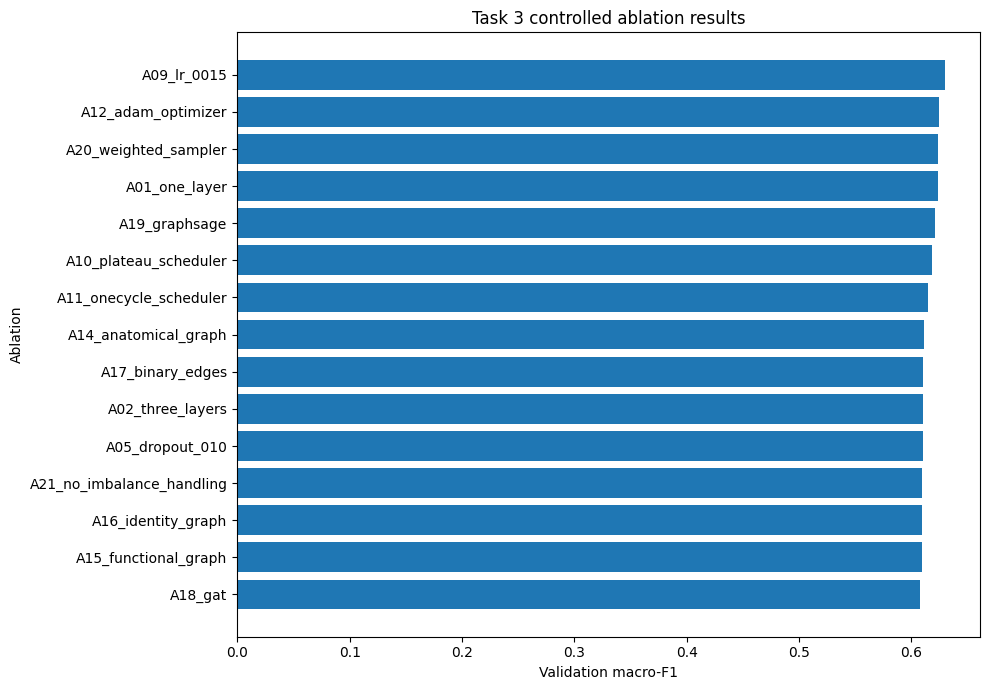

In [18]:
top_ablation = ablation_results.head(15).sort_values("f1_macro")

plt.figure(figsize=(10, 7))
plt.barh(top_ablation["ablation_id"], top_ablation["f1_macro"])
plt.xlabel("Validation macro-F1")
plt.ylabel("Ablation")
plt.title("Task 3 controlled ablation results")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "task3_ablation_macro_f1.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()


## 20. Five-fold subject-level cross-validation


In [19]:
BASELINE_CONFIG = {
    "dropout": 0.20,
    "learning_rate": 8e-4,
    "scheduler": "onecycle",
    "optimizer": "adamw",
    "graph_method": "identity",
    "edge_mode": "weighted",
    "imbalance_handling": "class_weight",
    "early_stopping": True,
    "patience": 6,
    "label_smoothing": LABEL_SMOOTHING,
    "seed": SEED,
}

FIRST_GNN_CONFIG = {
    "dropout": 0.20,
    "learning_rate": 8e-4,
    "scheduler": "onecycle",
    "optimizer": "adamw",
    "graph_method": "hybrid",
    "edge_mode": "weighted",
    "anatomical_weight": 0.40,
    "functional_weight": 0.60,
    "functional_k": 8,
    "imbalance_handling": "class_weight",
    "early_stopping": True,
    "patience": 6,
    "label_smoothing": LABEL_SMOOTHING,
    "seed": SEED,
}

DEVELOPMENT_IDX = np.sort(
    np.concatenate([TASK2_TRAIN_IDX, TASK2_VAL_IDX])
)
development_groups = SUBJECTS[DEVELOPMENT_IDX]

outer_cv = GroupKFold(n_splits=N_SPLITS)
outer_splits = list(
    outer_cv.split(
        DEVELOPMENT_IDX,
        Y[DEVELOPMENT_IDX],
        groups=development_groups,
    )
)

fold_audit = []
for fold, (outer_train_local, outer_test_local) in enumerate(outer_splits, 1):
    outer_train_idx = DEVELOPMENT_IDX[outer_train_local]
    outer_test_idx = DEVELOPMENT_IDX[outer_test_local]
    fold_audit.append(
        {
            "fold": fold,
            "outer_train_trials": len(outer_train_idx),
            "outer_test_trials": len(outer_test_idx),
            "outer_train_subjects": len(np.unique(SUBJECTS[outer_train_idx])),
            "outer_test_subjects": len(np.unique(SUBJECTS[outer_test_idx])),
            "subject_overlap": len(
                subject_set(outer_train_idx) & subject_set(outer_test_idx)
            ),
        }
    )

fold_audit = pd.DataFrame(fold_audit)
display(fold_audit)
assert fold_audit["subject_overlap"].sum() == 0


,fold,outer_train_trials,outer_test_trials,outer_train_subjects,outer_test_subjects,subject_overlap
0,1,3073,767,73,18,0
1,2,3075,765,73,18,0
2,3,3060,780,72,19,0
3,4,3076,764,73,18,0
4,5,3076,764,73,18,0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 21. Execute paired five-fold comparison


In [20]:
cv_metrics_path = TABLE_DIR / "task3_cv_fold_metrics.csv"
oof_predictions_path = TABLE_DIR / "task3_oof_predictions.csv"
cv_manifest_path = TABLE_DIR / "task3_cv_manifest.csv"
cv_history_path = TABLE_DIR / "task3_cv_histories.csv"

if RUN_FIVE_FOLD_CV:
    cv_rows = []
    oof_rows = []
    manifest_rows = []
    history_rows = []

    model_configs = {
        BEST_BASELINE_NAME: BASELINE_CONFIG,
        FIRST_GNN_NAME: FIRST_GNN_CONFIG,
        FINAL_GNN_NAME: FINAL_CONFIG,
    }

    for fold, (outer_train_local, outer_test_local) in enumerate(
        outer_splits, 1
    ):
        outer_train_idx = DEVELOPMENT_IDX[outer_train_local]
        outer_test_idx = DEVELOPMENT_IDX[outer_test_local]

        inner_splitter = GroupShuffleSplit(
            n_splits=1,
            test_size=INNER_VALIDATION_SIZE,
            random_state=SEED + fold,
        )
        inner_train_local, inner_val_local = next(
            inner_splitter.split(
                outer_train_idx,
                Y[outer_train_idx],
                groups=SUBJECTS[outer_train_idx],
            )
        )
        inner_train_idx = outer_train_idx[inner_train_local]
        inner_val_idx = outer_train_idx[inner_val_local]

        assert not (
            subject_set(inner_train_idx) & subject_set(inner_val_idx)
        )
        assert not (
            subject_set(inner_train_idx) & subject_set(outer_test_idx)
        )
        assert not (
            subject_set(inner_val_idx) & subject_set(outer_test_idx)
        )

        for model_name, template_config in model_configs.items():
            print("\n" + "#" * 90)
            print(f"Fold {fold}/{N_SPLITS} | {model_name}")

            config = deepcopy(template_config)
            config["seed"] = SEED + fold

            bundle = make_fold_bundle(
                inner_train_idx,
                inner_val_idx,
                outer_test_idx,
                config,
                seed=SEED + fold,
            )
            safe_model_name = re.sub(
                r"[^a-zA-Z0-9]+", "_", model_name
            ).strip("_").lower()
            checkpoint_path = (
                MODEL_DIR / f"fold_{fold}_{safe_model_name}.pt"
            )

            model, history, checkpoint = train_model(
                model_name,
                config,
                bundle,
                epochs=CV_EPOCHS,
                checkpoint_path=checkpoint_path,
            )

            test_probs, test_labels, test_indices, inference_seconds = (
                predict_probabilities(model, bundle.test_loader)
            )
            metrics = probability_metrics(test_labels, test_probs)

            cv_rows.append(
                {
                    "fold": fold,
                    "model": model_name,
                    **metrics,
                    "best_epoch": checkpoint["best_epoch"],
                    "training_seconds": checkpoint["training_seconds"],
                    "inference_seconds": inference_seconds,
                    "parameters": checkpoint["parameters"],
                    "train_subjects": len(
                        np.unique(SUBJECTS[inner_train_idx])
                    ),
                    "validation_subjects": len(
                        np.unique(SUBJECTS[inner_val_idx])
                    ),
                    "outer_test_subjects": len(
                        np.unique(SUBJECTS[outer_test_idx])
                    ),
                }
            )

            predictions = test_probs.argmax(axis=1)
            for row_index, global_index in enumerate(test_indices):
                oof_rows.append(
                    {
                        "fold": fold,
                        "model": model_name,
                        "global_index": int(global_index),
                        "subject": SUBJECTS[global_index],
                        "true_label": int(test_labels[row_index]),
                        "predicted_label": int(predictions[row_index]),
                        "correct": bool(
                            predictions[row_index] == test_labels[row_index]
                        ),
                        **{
                            f"probability_class_{class_id}": float(
                                test_probs[row_index, class_id]
                            )
                            for class_id in range(N_CLASSES)
                        },
                        "checkpoint": str(checkpoint_path),
                    }
                )

            manifest_rows.append(
                {
                    "fold": fold,
                    "model": model_name,
                    "checkpoint": str(checkpoint_path),
                    "inner_train_indices": json.dumps(
                        inner_train_idx.tolist()
                    ),
                    "inner_validation_indices": json.dumps(
                        inner_val_idx.tolist()
                    ),
                    "outer_test_indices": json.dumps(
                        outer_test_idx.tolist()
                    ),
                }
            )
            history["fold"] = fold
            history["model"] = model_name
            history_rows.append(history)

            del model, bundle
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    cv_metrics = pd.DataFrame(cv_rows)
    oof_predictions = pd.DataFrame(oof_rows)
    cv_manifest = pd.DataFrame(manifest_rows)
    cv_histories = pd.concat(history_rows, ignore_index=True)

    cv_metrics.to_csv(cv_metrics_path, index=False)
    oof_predictions.to_csv(oof_predictions_path, index=False)
    cv_manifest.to_csv(cv_manifest_path, index=False)
    cv_histories.to_csv(cv_history_path, index=False)
else:
    cv_metrics = pd.read_csv(cv_metrics_path)
    oof_predictions = pd.read_csv(oof_predictions_path)
    cv_manifest = pd.read_csv(cv_manifest_path)

display(cv_metrics.sort_values(["model", "fold"]))



##########################################################################################
Fold 1/5 | 1D-CNN


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)


1D-CNN | epoch 01/20 | train F1=0.3590 | val F1=0.3791


/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


1D-CNN | epoch 02/20 | train F1=0.4746 | val F1=0.4699


...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Task 3 Laterality-Aware ST-GNN | epoch 11/20 | train F1=0.6765 | val F1=0.5725
Early stopping at epoch 11.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,fold,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,mcc,cohen_kappa,log_loss,roc_auc,best_epoch,training_seconds,inference_seconds,parameters,train_subjects,validation_subjects,outer_test_subjects
0,1,1D-CNN,0.726206,0.726313,0.726507,0.726313,0.726168,0.726147,0.452821,0.452519,0.914018,0.778684,17,41.589434,0.191430,166850,62,11,18
3,2,1D-CNN,0.700654,0.700162,0.702647,0.700162,0.699567,0.699733,0.402801,0.400698,0.729289,0.772274,18,41.168850,0.180868,166850,62,11,18
6,3,1D-CNN,0.669231,0.669485,0.671105,0.669485,0.668525,0.668446,0.340586,0.338792,0.681897,0.725121,8,28.799685,0.260522,166850,61,11,19
9,4,1D-CNN,0.687173,0.686609,0.690695,0.686609,0.685296,0.685487,0.377282,0.373624,0.964955,0.733071,17,40.726202,0.181195,166850,62,11,18
12,5,1D-CNN,0.689791,0.687267,0.709672,0.687267,0.680394,0.681255,0.396306,0.376376,1.149502,0.767842,16,40.203355,0.178628,166850,62,11,18
1,1,First Hybrid ST-GNN,0.501956,0.502240,0.502258,0.502240,0.501141,0.501009,0.004498,0.004478,0.692842,0.515891,1,175.996870,2.476490,285191,62,11,18
4,2,First Hybrid ST-GNN,0.499346,0.500154,0.500159,0.500154,0.495818,0.495432,0.000312,0.000307,0.693293,0.511648,4,250.159581,2.482994,285191,62,11,18
7,3,First Hybrid ST-GNN,0.508974,0.509507,0.509935,0.509507,0.503885,0.503628,0.019438,0.018994,0.695133,0.502163,6,298.655688,2.524061,285191,61,11,19
10,4,First Hybrid ST-GNN,0.500000,0.498037,0.497382,0.498037,0.465539,0.466604,-0.004534,-0.003942,0.696193,0.474879,6,300.638712,2.473402,285191,62,11,18
13,5,First Hybrid ST-GNN,0.502618,0.503112,0.503124,0.503112,0.502342,0.502157,0.006236,0.006216,0.698643,0.506118,2,202.985170,2.488964,285191,62,11,18


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 22. Report five-fold mean ± standard deviation


,model,folds,accuracy_mean,accuracy_std,accuracy_mean_std,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_mean_std,precision_macro_mean,precision_macro_std,...,roc_auc_mean_std,log_loss_mean,log_loss_std,log_loss_mean_std,training_seconds_mean,training_seconds_std,training_seconds_mean_std,inference_seconds_mean,inference_seconds_std,inference_seconds_mean_std
0,1D-CNN,5,0.694611,0.020961,0.6946 ± 0.0210,0.693967,0.021113,0.6940 ± 0.0211,0.700125,0.020764,...,0.7554 ± 0.0245,0.887932,0.188845,0.8879 ± 0.1888,38.497505,5.445659,38.4975 ± 5.4457,0.198529,0.035007,0.1985 ± 0.0350
2,Task 3 Laterality-Aware ST-GNN,5,0.590826,0.020408,0.5908 ± 0.0204,0.590974,0.020160,0.5910 ± 0.0202,0.594082,0.021352,...,0.6289 ± 0.0325,0.671517,0.010294,0.6715 ± 0.0103,49.093224,13.111944,49.0932 ± 13.1119,0.298631,0.005587,0.2986 ± 0.0056
1,First Hybrid ST-GNN,5,0.502579,0.003821,0.5026 ± 0.0038,0.502610,0.004327,0.5026 ± 0.0043,0.502572,0.004674,...,0.5021 ± 0.0161,0.695221,0.002347,0.6952 ± 0.0023,245.687204,55.958773,245.6872 ± 55.9588,2.489182,0.020402,2.4892 ± 0.0204


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


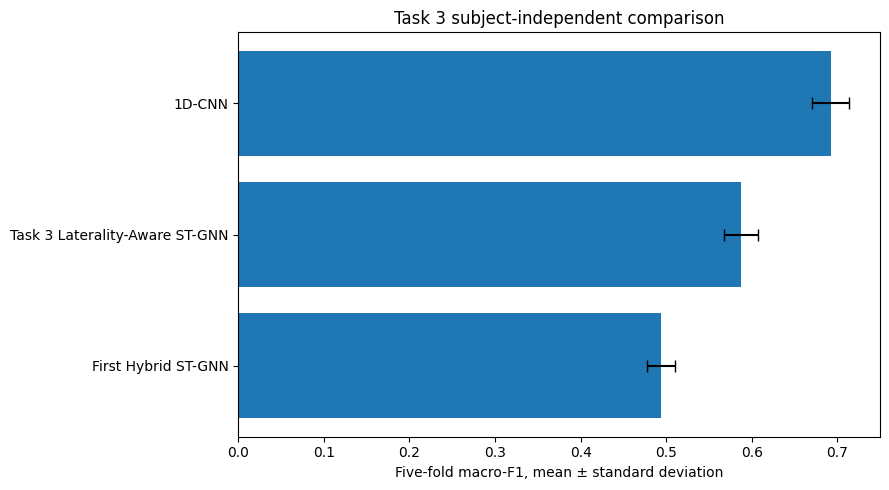

In [21]:
metric_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "f1_weighted",
    "mcc",
    "cohen_kappa",
    "roc_auc",
    "log_loss",
    "training_seconds",
    "inference_seconds",
]

summary_rows = []
for model_name, group in cv_metrics.groupby("model"):
    row = {"model": model_name, "folds": len(group)}
    for column in metric_columns:
        row[f"{column}_mean"] = group[column].mean()
        row[f"{column}_std"] = group[column].std(ddof=1)
        row[f"{column}_mean_std"] = (
            f"{group[column].mean():.4f} ± "
            f"{group[column].std(ddof=1):.4f}"
        )
    summary_rows.append(row)

cv_summary = pd.DataFrame(summary_rows).sort_values(
    "f1_macro_mean", ascending=False
)
display(cv_summary)

cv_summary.to_csv(
    TABLE_DIR / "task3_cv_summary_mean_std.csv",
    index=False,
)

plot_frame = cv_summary.sort_values("f1_macro_mean")
plt.figure(figsize=(9, 5))
plt.barh(
    plot_frame["model"],
    plot_frame["f1_macro_mean"],
    xerr=plot_frame["f1_macro_std"],
    capsize=4,
)
plt.xlabel("Five-fold macro-F1, mean ± standard deviation")
plt.title("Task 3 subject-independent comparison")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "task3_cv_macro_f1_comparison.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()


## 23. Subject-level paired significance test against the best baseline


In [22]:
subject_metric_rows = []

for (model_name, subject), group in oof_predictions.groupby(
    ["model", "subject"]
):
    y_true = group["true_label"].to_numpy()
    y_pred = group["predicted_label"].to_numpy()
    subject_metric_rows.append(
        {
            "model": model_name,
            "subject": subject,
            "trials": len(group),
            "accuracy": accuracy_score(y_true, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "f1_macro": f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            ),
        }
    )

subject_metrics = pd.DataFrame(subject_metric_rows)
subject_metrics.to_csv(
    TABLE_DIR / "task3_subject_level_metrics.csv",
    index=False,
)

baseline_subject = subject_metrics[
    subject_metrics["model"] == BEST_BASELINE_NAME
][["subject", "accuracy"]].rename(
    columns={"accuracy": "baseline_accuracy"}
)
final_subject = subject_metrics[
    subject_metrics["model"] == FINAL_GNN_NAME
][["subject", "accuracy"]].rename(
    columns={"accuracy": "final_gnn_accuracy"}
)

paired_subjects = baseline_subject.merge(
    final_subject,
    on="subject",
    how="inner",
)
paired_subjects["difference"] = (
    paired_subjects["final_gnn_accuracy"]
    - paired_subjects["baseline_accuracy"]
)

observed_difference, permutation_p = paired_sign_flip_test(
    paired_subjects["difference"],
    n_permutations=PERMUTATION_REPEATS,
    seed=SEED,
)
confidence_interval = subject_bootstrap_ci(
    paired_subjects["difference"],
    repeats=BOOTSTRAP_REPEATS,
    seed=SEED,
)

try:
    wilcoxon_result = stats.wilcoxon(
        paired_subjects["final_gnn_accuracy"],
        paired_subjects["baseline_accuracy"],
        alternative="two-sided",
        zero_method="wilcox",
    )
    wilcoxon_statistic = float(wilcoxon_result.statistic)
    wilcoxon_p = float(wilcoxon_result.pvalue)
except ValueError:
    wilcoxon_statistic = np.nan
    wilcoxon_p = np.nan

significance_results = {
    "comparison": f"{FINAL_GNN_NAME} minus {BEST_BASELINE_NAME}",
    "paired_subjects": int(len(paired_subjects)),
    "mean_subject_accuracy_difference": observed_difference,
    "bootstrap_95_percent_ci": confidence_interval,
    "paired_sign_flip_permutation_p_value": permutation_p,
    "wilcoxon_statistic_supplementary": wilcoxon_statistic,
    "wilcoxon_p_value_supplementary": wilcoxon_p,
    "primary_test": "paired subject-level sign-flip randomization test",
    "unit_of_analysis": "subject",
}

display(pd.Series(significance_results).to_frame("value"))
paired_subjects.to_csv(
    TABLE_DIR / "task3_paired_subject_accuracy.csv",
    index=False,
)

with open(
    OUTPUT_DIR / "task3_significance_results.json",
    "w",
    encoding="utf-8",
) as handle:
    json.dump(significance_results, handle, indent=2)


,value
comparison,Task 3 Laterality-Aware ST-GNN minus 1D-CNN
paired_subjects,91
mean_subject_accuracy_difference,-0.104765
bootstrap_95_percent_ci,"(-0.12868013390085398, -0.08124439778301276)"
paired_sign_flip_permutation_p_value,0.00002
wilcoxon_statistic_supplementary,333.5
wilcoxon_p_value_supplementary,0.0
primary_test,paired subject-level sign-flip randomization test
unit_of_analysis,subject


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 24. Related-work comparison

Do not insert an accuracy from a paper unless its dataset, task, split, and subject population are sufficiently comparable. A trial-random result must not be presented as equivalent to subject-independent five-fold performance.

Place a verified `related_work_task3.csv` file beside the notebook, or edit the template below. Recommended columns are retained so that protocol differences remain visible.


In [23]:
related_work_path_candidates = [
    Path("related_work_task3.csv"),
    Path("/kaggle/input/related-work/related_work_task3.csv"),
    OUTPUT_DIR / "related_work_task3.csv",
]
related_work_path = next(
    (path for path in related_work_path_candidates if path.exists()),
    None,
)

if related_work_path is not None:
    related_work = pd.read_csv(related_work_path)
else:
    related_work = pd.DataFrame(
        [
            {
                "study": "Task 3 final GNN",
                "year": 2026,
                "dataset": "EEGMMIDB",
                "task": "Left vs right fist execution",
                "protocol": "Subject-independent 5-fold CV",
                "subjects": len(np.unique(SUBJECTS[DEVELOPMENT_IDX])),
                "accuracy": cv_summary.loc[
                    cv_summary["model"] == FINAL_GNN_NAME,
                    "accuracy_mean",
                ].iloc[0],
                "macro_f1": cv_summary.loc[
                    cv_summary["model"] == FINAL_GNN_NAME,
                    "f1_macro_mean",
                ].iloc[0],
                "source": "This executed notebook",
                "fairly_comparable": True,
            },
            {
                "study": "Add verified related study",
                "year": np.nan,
                "dataset": "",
                "task": "",
                "protocol": "",
                "subjects": np.nan,
                "accuracy": np.nan,
                "macro_f1": np.nan,
                "source": "",
                "fairly_comparable": False,
            },
        ]
    )

display(related_work)
related_work.to_csv(
    TABLE_DIR / "task3_related_work_comparison.csv",
    index=False,
)


,study,year,dataset,task,protocol,subjects,accuracy,macro_f1,source,fairly_comparable
0,Task 3 final GNN,2026.0,EEGMMIDB,Left vs right fist execution,Subject-independent 5-fold CV,91.0,0.590826,0.587703,This executed notebook,True
1,Add verified related study,NaN,,,,NaN,NaN,NaN,,False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 25. Select one correct and one incorrect final-GNN prediction


In [24]:
final_oof = oof_predictions[
    oof_predictions["model"] == FINAL_GNN_NAME
].copy()
probability_columns = [
    column
    for column in final_oof.columns
    if column.startswith("probability_class_")
]
final_oof["confidence"] = final_oof[probability_columns].max(axis=1)

correct_candidates = final_oof[final_oof["correct"]].sort_values(
    "confidence"
)
wrong_candidates = final_oof[~final_oof["correct"]].sort_values(
    "confidence"
)

if correct_candidates.empty:
    raise RuntimeError("No correct out-of-fold prediction is available.")
if wrong_candidates.empty:
    raise RuntimeError(
        "No incorrect out-of-fold prediction is available; "
        "choose the lowest-confidence correct case as the second explanation."
    )

correct_row = correct_candidates.iloc[len(correct_candidates) // 2]
wrong_row = wrong_candidates.iloc[len(wrong_candidates) // 2]

explanation_selection = pd.DataFrame(
    [
        {
            "case": "correct",
            **correct_row.to_dict(),
        },
        {
            "case": "wrong",
            **wrong_row.to_dict(),
        },
    ]
)
display(explanation_selection)
explanation_selection.to_csv(
    TABLE_DIR / "task3_explanation_samples.csv",
    index=False,
)


,case,fold,model,global_index,subject,true_label,predicted_label,correct,probability_class_0,probability_class_1,checkpoint,confidence
0,correct,4,Task 3 Laterality-Aware ST-GNN,1484,36,1,1,True,0.419201,0.580800,/kaggle/working/eeg_task3_output/models/fold_4...,0.580800
1,wrong,5,Task 3 Laterality-Aware ST-GNN,107,3,0,1,False,0.438373,0.561627,/kaggle/working/eeg_task3_output/models/fold_5...,0.561627


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 26. SHAP and LIME explanation utilities


In [25]:
import shap

def reconstruct_model_from_checkpoint(checkpoint_path):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )
    model = make_model(
        checkpoint["model_name"],
        checkpoint["adjacency"],
        checkpoint["model_config"],
    ).to(DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, checkpoint


class FixedSignalNodeFeatureWrapper(nn.Module):
    """
    Local explanation wrapper.

    The raw EEG of the selected sample is held fixed while SHAP/LIME perturb
    the interpretable 64 × F node-feature branch. The resulting explanation
    describes how node features affect the complete model prediction in the
    context of that fixed raw EEG sample.
    """
    def __init__(self, model, fixed_signal):
        super().__init__()
        self.model = model
        self.register_buffer("fixed_signal", fixed_signal)

    def forward(self, flat_node_features):
        batch = flat_node_features.shape[0]
        node_features = flat_node_features.reshape(
            batch, N_CHANNELS, N_NODE_FEATURES
        )
        signal = self.fixed_signal.expand(batch, -1, -1)
        logits = self.model(signal, node_features)
        return torch.softmax(logits, dim=1)


def normalized_sample(global_index, checkpoint):
    signal = (
        X[global_index]
        - checkpoint["channel_mean"][:, None]
    ) / checkpoint["channel_std"][:, None]
    node_features = (
        NODE_FEATURES[global_index]
        - checkpoint["feature_mean"][None, :]
    ) / checkpoint["feature_std"][None, :]

    signal_tensor = torch.tensor(
        signal[None, ...],
        dtype=torch.float32,
        device=DEVICE,
    )
    node_tensor = torch.tensor(
        node_features.reshape(1, -1),
        dtype=torch.float32,
        device=DEVICE,
    )
    return signal_tensor, node_tensor


def fold_background(checkpoint, maximum=24):
    train_indices = np.asarray(checkpoint["train_idx"], dtype=np.int64)
    rng = np.random.default_rng(SEED)
    if len(train_indices) > maximum:
        train_indices = rng.choice(
            train_indices, size=maximum, replace=False
        )
    normalized = (
        NODE_FEATURES[train_indices]
        - checkpoint["feature_mean"][None, None, :]
    ) / checkpoint["feature_std"][None, None, :]
    return torch.tensor(
        normalized.reshape(len(train_indices), -1),
        dtype=torch.float32,
        device=DEVICE,
    )


def extract_target_shap(shap_values, target_class):
    if isinstance(shap_values, list):
        return np.asarray(shap_values[target_class])[0]

    values = np.asarray(shap_values)
    if values.ndim == 3 and values.shape[-1] == N_CLASSES:
        return values[0, :, target_class]
    if values.ndim == 3 and values.shape[0] == N_CLASSES:
        return values[target_class, 0]
    if values.ndim == 2:
        return values[0]
    raise ValueError(f"Unexpected SHAP shape: {values.shape}")


def local_lime_weights(
    sample,
    predict_fn,
    target_class,
    background,
    n_samples=1000,
    seed=42,
):
    """
    LIME-style local surrogate for continuous tabular features.

    Perturbations are sampled around the selected observation using
    training-background standard deviations. A distance-weighted ridge
    regression approximates the model probability locally.
    """
    rng = np.random.default_rng(seed)
    background = np.asarray(background, dtype=np.float32)
    sample = np.asarray(sample, dtype=np.float32)

    feature_scale = np.std(background, axis=0)
    feature_scale = np.maximum(feature_scale, 0.05)

    perturbations = sample[None, :] + rng.normal(
        0.0,
        feature_scale[None, :],
        size=(n_samples, len(sample)),
    ).astype(np.float32)
    perturbations[0] = sample

    probabilities = predict_fn(perturbations)[:, target_class]
    standardized_distance = np.sqrt(
        np.mean(
            ((perturbations - sample[None, :]) / feature_scale[None, :]) ** 2,
            axis=1,
        )
    )
    kernel_width = math.sqrt(len(sample)) * 0.75
    sample_weights = np.exp(
        -(standardized_distance ** 2) / (kernel_width ** 2 + 1e-8)
    )

    surrogate = Ridge(alpha=1.0, fit_intercept=True)
    surrogate.fit(
        perturbations,
        probabilities,
        sample_weight=sample_weights,
    )
    return surrogate.coef_.astype(float)


def explain_prediction_with_shap_and_lime(case_row, case_name):
    global_index = int(case_row["global_index"])
    checkpoint_path = Path(case_row["checkpoint"])
    predicted_class = int(case_row["predicted_label"])

    model, checkpoint = reconstruct_model_from_checkpoint(checkpoint_path)
    signal_tensor, node_tensor = normalized_sample(global_index, checkpoint)
    background_tensor = fold_background(checkpoint)

    wrapper = FixedSignalNodeFeatureWrapper(
        model=model,
        fixed_signal=signal_tensor,
    ).to(DEVICE)
    wrapper.eval()

    feature_names = [
        f"{channel}__{feature}"
        for channel in CHANNEL_NAMES
        for feature in NODE_FEATURE_NAMES
    ]

    # SHAP GradientExplainer
    shap_explainer = shap.GradientExplainer(
        wrapper,
        background_tensor,
    )
    shap_values = shap_explainer.shap_values(node_tensor)
    shap_vector = extract_target_shap(
        shap_values,
        target_class=predicted_class,
    )

    # LIME-style local surrogate on the same node-feature branch.
    background_np = background_tensor.detach().cpu().numpy()
    sample_np = node_tensor.detach().cpu().numpy()[0]

    def lime_predict(flat_features):
        tensor = torch.tensor(
            flat_features,
            dtype=torch.float32,
            device=DEVICE,
        )
        with torch.no_grad():
            return wrapper(tensor).cpu().numpy()

    lime_vector = local_lime_weights(
        sample=sample_np,
        predict_fn=lime_predict,
        target_class=predicted_class,
        background=background_np,
        n_samples=1000,
        seed=SEED,
    )

    # Aggregate absolute attribution by channel.
    shap_channel = np.abs(shap_vector).reshape(
        N_CHANNELS, N_NODE_FEATURES
    ).sum(axis=1)
    lime_channel = np.abs(lime_vector).reshape(
        N_CHANNELS, N_NODE_FEATURES
    ).sum(axis=1)

    shap_order = np.argsort(shap_channel)[-15:]
    lime_order = np.argsort(lime_channel)[-15:]

    plt.figure(figsize=(8, 6))
    plt.barh(
        np.asarray(CHANNEL_NAMES)[shap_order],
        shap_channel[shap_order],
    )
    plt.xlabel("Sum of absolute SHAP attribution")
    plt.title(
        f"SHAP channel importance — {case_name} prediction\n"
        f"True: {CLASS_NAMES[int(case_row['true_label'])]} | "
        f"Predicted: {CLASS_NAMES[predicted_class]}"
    )
    plt.tight_layout()
    shap_figure = (
        FIGURE_DIR / f"task3_shap_{case_name}_prediction.png"
    )
    plt.savefig(shap_figure, dpi=220, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.barh(
        np.asarray(CHANNEL_NAMES)[lime_order],
        lime_channel[lime_order],
    )
    plt.xlabel("Sum of absolute LIME surrogate weight")
    plt.title(
        f"LIME channel importance — {case_name} prediction\n"
        f"True: {CLASS_NAMES[int(case_row['true_label'])]} | "
        f"Predicted: {CLASS_NAMES[predicted_class]}"
    )
    plt.tight_layout()
    lime_figure = (
        FIGURE_DIR / f"task3_lime_{case_name}_prediction.png"
    )
    plt.savefig(lime_figure, dpi=220, bbox_inches="tight")
    plt.show()

    attribution_table = pd.DataFrame(
        {
            "feature": feature_names,
            "shap_value": shap_vector,
            "lime_weight": lime_vector,
            "absolute_shap": np.abs(shap_vector),
            "absolute_lime": np.abs(lime_vector),
        }
    ).sort_values("absolute_shap", ascending=False)
    attribution_table.to_csv(
        TABLE_DIR / f"task3_{case_name}_shap_lime_features.csv",
        index=False,
    )

    del model, wrapper
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "case": case_name,
        "global_index": global_index,
        "true_class": CLASS_NAMES[int(case_row["true_label"])],
        "predicted_class": CLASS_NAMES[predicted_class],
        "confidence": float(case_row["confidence"]),
        "shap_figure": str(shap_figure),
        "lime_figure": str(lime_figure),
    }


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 27. Explain one correct and one wrong sample


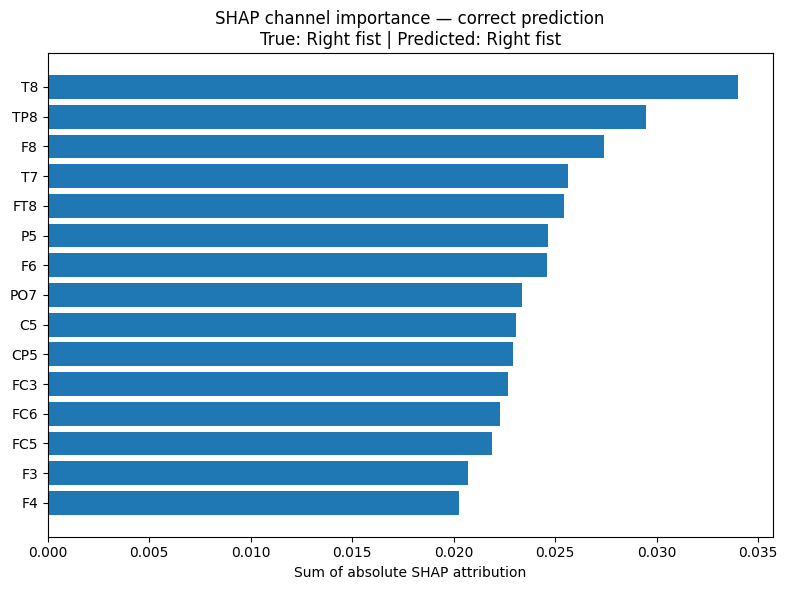

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


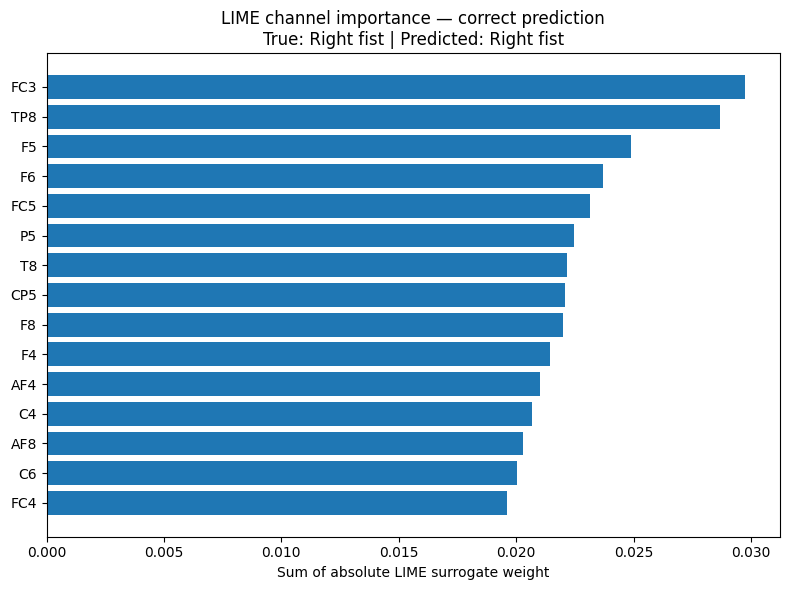

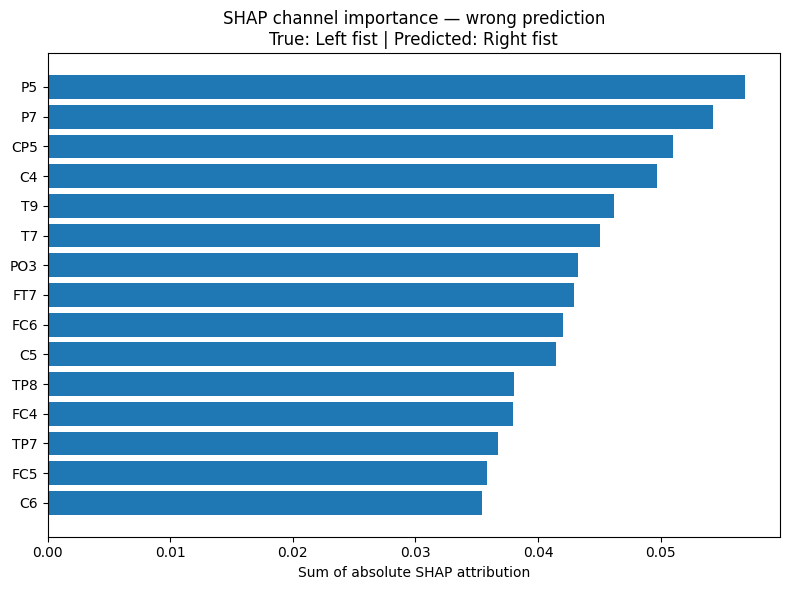

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


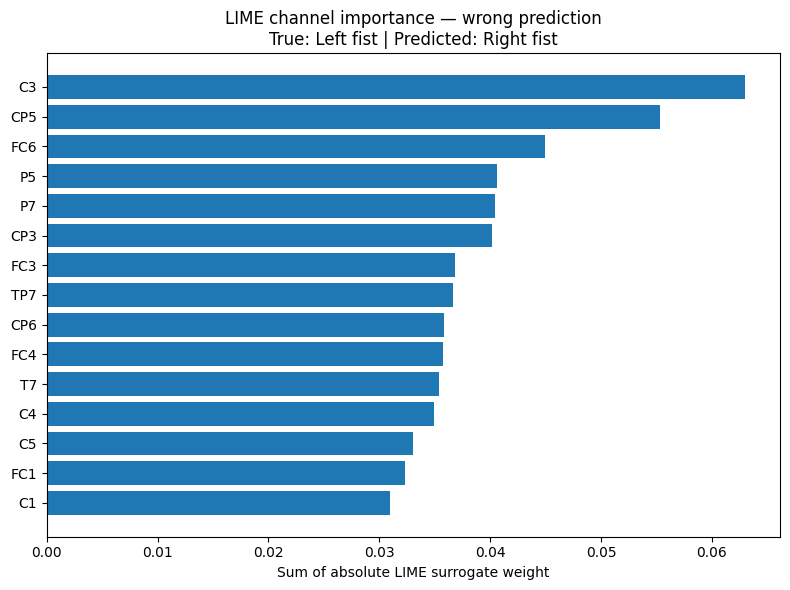

,case,global_index,true_class,predicted_class,confidence,shap_figure,lime_figure
0,correct,1484,Right fist,Right fist,0.580800,/kaggle/working/eeg_task3_output/figures/task3...,/kaggle/working/eeg_task3_output/figures/task3...
1,wrong,107,Left fist,Right fist,0.561627,/kaggle/working/eeg_task3_output/figures/task3...,/kaggle/working/eeg_task3_output/figures/task3...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [26]:
if RUN_EXPLAINABILITY:
    explanation_outputs = [
        explain_prediction_with_shap_and_lime(
            correct_row,
            "correct",
        ),
        explain_prediction_with_shap_and_lime(
            wrong_row,
            "wrong",
        ),
    ]
    explanation_outputs = pd.DataFrame(explanation_outputs)
    display(explanation_outputs)
    explanation_outputs.to_csv(
        TABLE_DIR / "task3_explanation_outputs.csv",
        index=False,
    )
else:
    print("RUN_EXPLAINABILITY is False.")


## 28. Confusion matrices from paired out-of-fold predictions


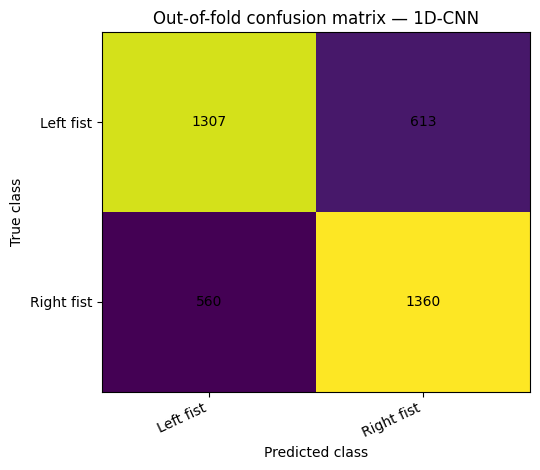

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


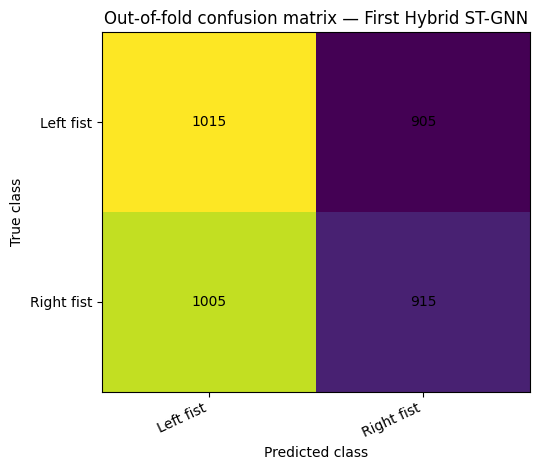

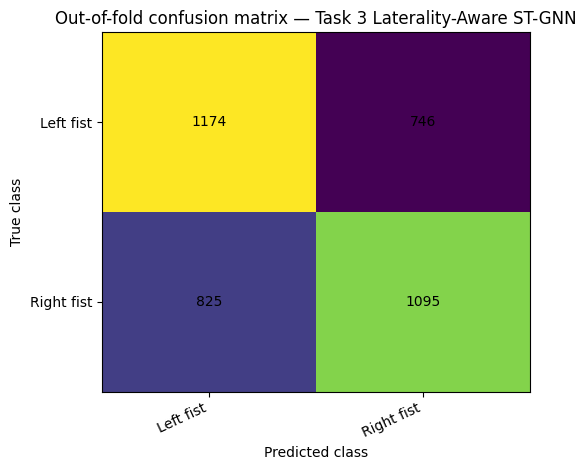

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [27]:
for model_name in [
    BEST_BASELINE_NAME,
    FIRST_GNN_NAME,
    FINAL_GNN_NAME,
]:
    model_oof = oof_predictions[
        oof_predictions["model"] == model_name
    ].sort_values("global_index")
    matrix = confusion_matrix(
        model_oof["true_label"],
        model_oof["predicted_label"],
        labels=np.arange(N_CLASSES),
    )

    plt.figure(figsize=(5.5, 4.8))
    plt.imshow(matrix, aspect="auto")
    plt.xticks(
        np.arange(N_CLASSES),
        CLASS_NAMES,
        rotation=25,
        ha="right",
    )
    plt.yticks(np.arange(N_CLASSES), CLASS_NAMES)
    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.title(f"Out-of-fold confusion matrix — {model_name}")

    for row in range(N_CLASSES):
        for column in range(N_CLASSES):
            plt.text(
                column,
                row,
                matrix[row, column],
                ha="center",
                va="center",
            )

    plt.tight_layout()
    safe_name = re.sub(
        r"[^a-zA-Z0-9]+", "_", model_name
    ).strip("_").lower()
    plt.savefig(
        FIGURE_DIR / f"task3_oof_confusion_{safe_name}.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()


## 29. Automated report-ready interpretation


In [28]:
best_row = cv_summary.iloc[0]
final_row = cv_summary[
    cv_summary["model"] == FINAL_GNN_NAME
].iloc[0]
baseline_row = cv_summary[
    cv_summary["model"] == BEST_BASELINE_NAME
].iloc[0]
first_gnn_row = cv_summary[
    cv_summary["model"] == FIRST_GNN_NAME
].iloc[0]

interpretation = f"""
# Task 3 measured-results summary

## Ablation selection
The final configuration was selected as `{best_ablation_id}` using validation
macro-F1 only. No Task 2 test labels or outer-fold labels were used for this
selection.

## Five-fold subject-independent performance
- Final Task 3 GNN macro-F1:
  {final_row['f1_macro_mean']:.4f} ± {final_row['f1_macro_std']:.4f}
- Best baseline ({BEST_BASELINE_NAME}) macro-F1:
  {baseline_row['f1_macro_mean']:.4f} ± {baseline_row['f1_macro_std']:.4f}
- First Task 2 GNN macro-F1:
  {first_gnn_row['f1_macro_mean']:.4f} ± {first_gnn_row['f1_macro_std']:.4f}

## Paired significance analysis
The mean subject-level accuracy difference between the final GNN and the
baseline was {observed_difference:.4f}. The subject-bootstrap 95% confidence
interval was [{confidence_interval[0]:.4f}, {confidence_interval[1]:.4f}].
The paired sign-flip randomization-test p-value was {permutation_p:.6f}.

## Interpretation rule
A p-value below 0.05 and a confidence interval excluding zero support a
statistically detectable difference at the subject level. Statistical
significance does not by itself establish practical or clinical importance.
Results must be compared with related studies only when task and validation
protocols are sufficiently similar.
""".strip()

print(interpretation)
with open(
    OUTPUT_DIR / "task3_report_ready_summary.md",
    "w",
    encoding="utf-8",
) as handle:
    handle.write(interpretation + "\n")


# Task 3 measured-results summary

## Ablation selection
The final configuration was selected as `A09_lr_0015` using validation
macro-F1 only. No Task 2 test labels or outer-fold labels were used for this
selection.

## Five-fold subject-independent performance
- Final Task 3 GNN macro-F1:
  0.5877 ± 0.0196
- Best baseline (1D-CNN) macro-F1:
  0.6920 ± 0.0221
- First Task 2 GNN macro-F1:
  0.4937 ± 0.0161

## Paired significance analysis
The mean subject-level accuracy difference between the final GNN and the
baseline was -0.1048. The subject-bootstrap 95% confidence
interval was [-0.1287, -0.0812].
The paired sign-flip randomization-test p-value was 0.000020.

## Interpretation rule
A p-value below 0.05 and a confidence interval excluding zero support a
statistically detectable difference at the subject level. Statistical
significance does not by itself establish practical or clinical importance.
Results must be compared with related studies only when task and validation
protocols are

## 30. Final output inventory and completion checks


In [29]:
required_outputs = [
    TABLE_DIR / "task3_ablation_results.csv",
    TABLE_DIR / "task3_cv_fold_metrics.csv",
    TABLE_DIR / "task3_cv_summary_mean_std.csv",
    TABLE_DIR / "task3_oof_predictions.csv",
    TABLE_DIR / "task3_subject_level_metrics.csv",
    OUTPUT_DIR / "task3_significance_results.json",
    OUTPUT_DIR / "selected_task3_configuration.json",
    OUTPUT_DIR / "task3_report_ready_summary.md",
    FIGURE_DIR / "task3_stgnn_architecture.png",
    FIGURE_DIR / "task3_cv_macro_f1_comparison.png",
]

completion = pd.DataFrame(
    {
        "output": [str(path) for path in required_outputs],
        "exists": [path.exists() for path in required_outputs],
    }
)
display(completion)

if not completion["exists"].all():
    print(
        "Some outputs are missing because their corresponding execution "
        "control may be False or an earlier cell may not have completed."
    )
else:
    print("Task 3 notebook completed successfully.")


,output,exists
0,/kaggle/working/eeg_task3_output/tables/task3_...,True
1,/kaggle/working/eeg_task3_output/tables/task3_...,True
2,/kaggle/working/eeg_task3_output/tables/task3_...,True
3,/kaggle/working/eeg_task3_output/tables/task3_...,True
4,/kaggle/working/eeg_task3_output/tables/task3_...,True
5,/kaggle/working/eeg_task3_output/task3_signifi...,True
6,/kaggle/working/eeg_task3_output/selected_task...,True
7,/kaggle/working/eeg_task3_output/task3_report_...,True
8,/kaggle/working/eeg_task3_output/figures/task3...,True
9,/kaggle/working/eeg_task3_output/figures/task3...,True


Task 3 notebook completed successfully.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Methodological interpretation

This notebook improves the Task 2 experiment in four important ways:

1. **The correct comparator is used.** The 1D-CNN is treated as the baseline to beat.
2. **The redesigned GNN preserves laterality.** Electrode identity, hemisphere, motor-region encoding, and left–right readout are explicit.
3. **Every fold is leakage-safe.** Scaling and functional graph construction use inner-training subjects only.
4. **The statistical unit is the subject.** The primary significance test uses paired subject-level differences rather than treating correlated trials as independent observations.

SHAP and LIME are local explanations of the interpretable node-feature branch while the selected sample's raw EEG is held fixed. They explain model reliance, not biological causation.
